# Causal feature engineering from original meter records

All source parsing, causal alignment, provenance, chronological boundaries and feature construction are executable here. The published interpolated CSV is retained only for a clearly labelled secondary reference. No supplied interpolation enters inputs.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
PROJECT_DIR=_repo_root()
TABLE_DIR=PROJECT_DIR/'.cache/experiment/tables'; STATE_DIR=PROJECT_DIR/'.cache/experiment/state'; FIGURE_DIR=PROJECT_DIR/'.cache/experiment/figures'
pd.set_option('display.max_rows',100);pd.set_option('display.max_columns',20);pd.set_option('display.max_colwidth',None)
plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.dpi':350,'savefig.dpi':350})
manifest=pd.read_csv(TABLE_DIR/'raw_meter_manifest.csv')


## Parse original records and preserve provenance
The official format is a 9-byte little-endian record: one flag byte, Unix seconds, float32 cumulative kWh. Original timestamp order, duplicate counts and non-finite records are checked. No retrospective supplier validation is applied.

In [2]:
feeds={}; audit=[]
for row in manifest.itertuples():
    f=PROJECT_DIR/row.local_path
    assert hashlib.sha256(f.read_bytes()).hexdigest()==row.sha256
    a=np.fromfile(f,dtype=np.dtype([('flag','u1'),('timestamp','<u4'),('energy','<f4')]))
    df=pd.DataFrame({'source_timestamp':pd.to_datetime(a['timestamp'],unit='s',utc=True).as_unit('ns'),'energy_kwh':a['energy'].astype(float)})
    valid=(df.source_timestamp.dt.year>2010)&np.isfinite(df.energy_kwh)
    duplicate=int(df.loc[valid,'source_timestamp'].duplicated().sum())
    df=df.loc[valid].drop_duplicates('source_timestamp',keep='last').sort_values('source_timestamp')
    feeds[(row.site,row.channel)]=df.reset_index(drop=True)
    audit.append({'site':row.site,'channel':row.channel,'n_records':len(a),'n_valid':len(df),'duplicate_timestamps':duplicate,'start':df.source_timestamp.min(),'end':df.source_timestamp.max()})
source_audit=pd.DataFrame(audit);source_audit.to_csv(TABLE_DIR/'raw_measurement_summary.csv',index=False)
display(source_audit[['site','channel','n_records','n_valid','duplicate_timestamps']])


,site,channel,n_records,n_valid,duplicate_timestamps
0,industrial1,grid_import,675959,675959,0
1,industrial1,pv_1,288546,288545,0
2,industrial1,pv_2,312788,312787,0
3,industrial2,grid_import,577499,577498,0
4,industrial2,pv,510597,510597,0
5,industrial2,storage_charge,560104,560104,0
6,industrial2,storage_decharge,560176,560176,0
7,industrial3,ev,508159,508159,0
8,industrial3,grid_import,599657,599657,0
9,industrial3,pv_facade,647285,647285,0


## Freeze common-calendar boundaries before transforms
The nine industrial/residential sites form the main cohort because the two public sites do not overlap. Published coverage conservatively limits the raw acquisition range. The four calendar fractions are 55% training, 15% selection, 15% calibration, 15% final test. Five expanding origins lie entirely before the final test. Public-site experiments require separate, explicitly labelled cohorts. No test score determines this choice.

In [3]:
coverage=pd.read_csv(TABLE_DIR/'common_calendar_site_coverage.csv',parse_dates=['start_utc','end_utc'])
sites=sorted(coverage.loc[~coverage.site.str.startswith('public'),'site'])
selected=coverage[coverage.site.isin(sites)]
start=selected.start_utc.max().ceil('15min')+pd.Timedelta(minutes=15)
end=selected.end_utc.min().floor('15min')
assert start<end
calendar=pd.date_range(start,end,freq='15min',tz='UTC')
boundaries=[calendar[int((len(calendar)-1)*f)] for f in [.55,.70,.85,1.0]]
starts=[start]+[x+pd.Timedelta(minutes=15) for x in boundaries[:-1]]
split_table=pd.DataFrame({'split':['train','validation','calibration','test'],'start':starts,'end':boundaries})
assert (split_table.start<=split_table.end).all()
protocol={'revision':'raw_causal_v1','sites':sites,'excluded_primary_sites':['public1','public2'],'cohort_reason':'No 11-site common interval; industrial/residential nine-site common cohort selected from availability, not outcomes.','splits':split_table.astype(str).to_dict('records'),'seeds':[11,23,37,53,71],'n_origins':5,'horizons':[1,4],'max_endpoint_age_seconds':180,'lags':[1,2,4,8,16,32,92,95,96],'rolling_windows':[4,16,96],'graph_neighbors':4,'threads':4,'alpha':.10,'target_definition':'Rate from the two most recent original cumulative snapshots at successive 15-minute calendar boundaries, divided by their actual elapsed duration. Endpoints are at most 180 s old. This is measurement-derived, asynchronously aligned interval power, not an exact synchronous 15-minute energy measurement.'}
(STATE_DIR/'experiment_config.json').write_text(json.dumps(protocol,indent=2))
split_table.to_csv(TABLE_DIR/'split_summary.csv',index=False)
display(split_table)
origin_rows=[]
for origin,fraction in enumerate(np.linspace(.35,.65,5),1):
    cuts=[calendar[int((len(calendar)-1)*x)] for x in [fraction,fraction+.05,fraction+.10,fraction+.15]]
    for j,name in enumerate(['train','validation','calibration','test']):
        origin_rows.append({'origin':origin,'split':name,'start':start if j==0 else cuts[j-1]+pd.Timedelta(minutes=15),'end':cuts[j]})
origins=pd.DataFrame(origin_rows)
assert origins.end.max()<split_table.loc[split_table.split.eq('test'),'start'].iloc[0]
origins.to_csv(TABLE_DIR/'rolling_origin_splits.csv',index=False)
display(origins)


,split,start,end
0,train,2016-05-13 13:45:00+00:00,2016-10-05 18:45:00+00:00
1,validation,2016-10-05 19:00:00+00:00,2016-11-14 09:15:00+00:00
2,calibration,2016-11-14 09:30:00+00:00,2016-12-23 23:45:00+00:00
3,test,2016-12-24 00:00:00+00:00,2017-02-01 14:30:00+00:00


,origin,split,start,end
0,1,train,2016-05-13 13:45:00+00:00,2016-08-13 23:30:00+00:00
1,1,validation,2016-08-13 23:45:00+00:00,2016-08-27 04:15:00+00:00
2,1,calibration,2016-08-27 04:30:00+00:00,2016-09-09 09:15:00+00:00
3,1,test,2016-09-09 09:30:00+00:00,2016-09-22 14:00:00+00:00
4,2,train,2016-05-13 13:45:00+00:00,2016-09-02 18:45:00+00:00
5,2,validation,2016-09-02 19:00:00+00:00,2016-09-15 23:30:00+00:00
6,2,calibration,2016-09-15 23:45:00+00:00,2016-09-29 04:30:00+00:00
7,2,test,2016-09-29 04:45:00+00:00,2016-10-12 09:15:00+00:00
8,3,train,2016-05-13 13:45:00+00:00,2016-09-22 14:00:00+00:00
9,3,validation,2016-09-22 14:15:00+00:00,2016-10-05 18:45:00+00:00


## Causal alignment of original cumulative readings
Each calendar boundary uses only the most recent original reading at or before that boundary. Missing or stale endpoints remain missing; no cumulative jump is spread backwards over a gap. A valid interval requires both endpoints no more than 180 s old, positive elapsed time, no counter decrease among intervening raw readings, and non-negative energy change. We retain endpoint ages and actual interval durations to expose asynchronous measurement uncertainty. These targets are **measurement-derived interval averages**, not exact synchronised 15-minute measurements.

In [4]:
def causal_channel(df,index,max_age_seconds=180):
    df=df.copy()
    df['reset_count']=(df.energy_kwh.diff()<0).cumsum()
    left=pd.DataFrame({'timestamp':pd.DatetimeIndex(index).as_unit('ns')})
    aligned=pd.merge_asof(left,df,left_on='timestamp',right_on='source_timestamp',direction='backward',allow_exact_matches=True)
    age=(aligned.timestamp-aligned.source_timestamp).dt.total_seconds()
    elapsed=aligned.source_timestamp.diff().dt.total_seconds()
    change=aligned.energy_kwh.diff()
    observed=age.le(max_age_seconds)&age.shift(1).le(max_age_seconds)&elapsed.gt(0)&change.ge(0)&aligned.reset_count.diff().eq(0)
    power=(change/(elapsed/3600)).where(observed)
    assert (aligned.source_timestamp.dropna()<=aligned.timestamp[aligned.source_timestamp.notna()]).all()
    return pd.DataFrame({'timestamp':index,'power_kw':power.to_numpy(),'observed':observed.to_numpy(),'source_timestamp':aligned.source_timestamp.to_numpy(),'age_seconds':age.to_numpy(),'interval_seconds':elapsed.to_numpy()})

# Three days of prehistory are allowed only as past context; no fitted statistics use this prehistory.
context=pd.date_range(start-pd.Timedelta(days=3),end,freq='15min',tz='UTC')
channel_panels={}
for (site,channel),df in feeds.items():
    if site in sites:
        channel_panels[(site,channel)]=causal_channel(df,context,protocol['max_endpoint_age_seconds'])
rows=[]
for site in sites:
    available=[c for s,c in channel_panels if s==site]
    def aggregate(names,absent_zero=False):
        if not names:return pd.Series(0. if absent_zero else np.nan,index=range(len(context)))
        frame=pd.concat([channel_panels[(site,c)].power_kw for c in names],axis=1)
        return frame.sum(axis=1,min_count=len(names))
    required=['grid_import']+(['grid_export'] if 'grid_export' in available else [])
    frame=pd.DataFrame({'timestamp':context,'site':site,'building_type':'industrial' if site.startswith('industrial') else 'residential'})
    frame['net_load_kw']=aggregate(['grid_import'])-aggregate(['grid_export'] if 'grid_export' in available else [],True)
    frame['pv_power_kw']=aggregate([c for c in available if c.startswith('pv')],True)
    frame['measured_current']=frame.net_load_kw.notna()
    frame['max_source_timestamp']=pd.concat([channel_panels[(site,c)].source_timestamp for c in available],axis=1).max(axis=1)
    frame['endpoint_age_seconds']=pd.concat([channel_panels[(site,c)].age_seconds for c in required],axis=1).max(axis=1)
    frame['endpoint_duration_min_seconds']=pd.concat([channel_panels[(site,c)].interval_seconds for c in required],axis=1).min(axis=1)
    frame['endpoint_duration_max_seconds']=pd.concat([channel_panels[(site,c)].interval_seconds for c in required],axis=1).max(axis=1)
    frame['missingness_ratio']=pd.concat([channel_panels[(site,c)].power_kw.isna() for c in available],axis=1).mean(axis=1)
    frame['split']='context'
    for row in split_table.itertuples():frame.loc[frame.timestamp.between(row.start,row.end),'split']=row.split
    for channel in ['storage_charge','storage_decharge','ev','heat_pump']:
        frame[channel+'_kw']=aggregate([channel] if channel in available else [],True)
    rows.append(frame)
base_panel=pd.concat(rows,ignore_index=True).sort_values(['site','timestamp']).reset_index(drop=True)
base_panel.to_parquet(TABLE_DIR/'causal_base_panel.parquet',index=False)
quality_summary=base_panel[base_panel.split.ne('context')].groupby(['site','split']).agg(n=('timestamp','size'),measured=('measured_current','sum'),median_endpoint_age_s=('endpoint_age_seconds','median'),min_net_load_kw=('net_load_kw','min'),max_net_load_kw=('net_load_kw','max')).reset_index()
quality_summary.to_csv(TABLE_DIR/'causal_alignment_quality.csv',index=False)
display(quality_summary)


,site,split,n,measured,median_endpoint_age_s,min_net_load_kw,max_net_load_kw
0,industrial1,calibration,3802,3802,20.0,6.000000,76.437500
1,industrial1,test,3803,3803,53.0,4.625000,55.875000
2,industrial1,train,13941,8100,25.0,0.000000,163.062500
3,industrial1,validation,3802,3802,24.0,6.500000,77.375000
4,industrial2,calibration,3802,3802,54.0,0.000000,9.156250
5,industrial2,test,3803,3803,46.0,0.000000,10.671875
6,industrial2,train,13941,12857,17.0,0.000000,11.390625
7,industrial2,validation,3802,3802,6.0,0.000000,7.515625
8,industrial3,calibration,3802,3802,56.0,31.964484,212.000000
9,industrial3,test,3803,3803,51.0,27.968923,214.238042


## Supplier-filled targets as a separate secondary reference
Supplier interpolation is never an input. Published left-labelled readings are moved to the end of the 15-minute bin before deriving this secondary reference. Its interpolation flags include both cumulative endpoints of every required import/export channel. Unmarked supplier data cannot certify measured targets because supplier short-gap interpolation was unmarked.

In [5]:
published=pd.read_csv(PROJECT_DIR/'dataset'/'household_data_15min_singleindex.csv.gz')
published_time=pd.to_datetime(published.utc_timestamp,utc=True)+pd.Timedelta(minutes=15)
markers=published.interpolated.fillna('').str.lower()
reference=[]
for site in sites:
    import_col=f'DE_KN_{site}_grid_import';export_col=f'DE_KN_{site}_grid_export'
    required=[import_col]+([export_col] if export_col in published else [])
    endpoint_flag=pd.concat([markers.str.contains(c.lower(),regex=False) for c in required],axis=1).any(axis=1)
    interpolation=endpoint_flag|endpoint_flag.shift(1,fill_value=False)
    changes=published[required].diff()
    valid=changes.notna().all(axis=1)&changes.ge(0).all(axis=1)
    ref=(changes[import_col]-(changes[export_col] if export_col in changes else 0))/.25
    reference.append(pd.DataFrame({'timestamp':published_time,'site':site,'supplier_target_reference_kw':ref.where(valid),'supplier_interpolated':interpolation}))
reference=pd.concat(reference,ignore_index=True)
base_panel=base_panel.drop(columns=['supplier_target_reference_kw','supplier_interpolated'],errors='ignore').merge(reference,on=['site','timestamp'],how='left',validate='one_to_one')
base_panel['supplier_interpolated']=base_panel.supplier_interpolated.fillna(False).astype(bool)
base_panel.to_parquet(TABLE_DIR/'causal_base_panel.parquet',index=False)
display(base_panel.groupby('site').agg(raw_available=('measured_current','sum'),supplier_interpolated_bins=('supplier_interpolated','sum')))


,raw_available,supplier_interpolated_bins
site,,
industrial1,19507,2742
industrial2,24551,0
industrial3,24471,188
residential1,25058,577
residential2,25429,207
residential3,24744,838
residential4,9202,3859
residential5,25245,259
residential6,25343,9


## Fold-local preprocessing, graph and target construction
Every fold refits anomaly thresholds, imputation statistics, regime thresholds and graph using its training calendar only. A deliberately broad statistical quality screen flags absolute interval power above 20 times the training 99th percentile. It is not a physical capacity claim. The unscreened observed target is retained for sensitivity evaluation; model selection/calibration use screened measurement-derived targets. All targets crossing a split boundary are purged. Neighbor context uses only current or earlier measurements, with a one-step delay variant.

In [6]:
def build_fold(base,boundary_table,graph_delay=0,anomaly_factor=20.):
    begin=time.perf_counter()
    p=base.copy().sort_values(['site','timestamp']).reset_index(drop=True)
    p['split']='context';p['split_end']=pd.NaT
    p['split_end']=pd.to_datetime(p['split_end'],utc=True)
    for r in boundary_table.itertuples():
        mask=p.timestamp.between(pd.Timestamp(r.start),pd.Timestamp(r.end))
        p.loc[mask,'split']=r.split;p.loc[mask,'split_end']=pd.Timestamp(r.end)
    tr=p.split.eq('train')
    assert tr.any()
    cap=p.loc[tr].groupby('site').net_load_kw.apply(lambda s:float(s.abs().quantile(.99))*anomaly_factor)
    p['raw_observed_net_load_kw']=p.net_load_kw
    p['raw_anomaly_flag']=p.net_load_kw.abs().gt(p.site.map(cap))
    p['net_load_kw']=p.net_load_kw.mask(p.raw_anomaly_flag)
    p['measured_current']=p.net_load_kw.notna()
    # The same broad train-only screening applies to auxiliary input channels.
    auxiliary=[c for c in ['pv_power_kw','storage_charge_kw','storage_decharge_kw','ev_kw','heat_pump_kw'] if c in p]
    aux_caps={}
    for col in auxiliary:
        limit=p.loc[tr].groupby('site')[col].apply(lambda s:max(float(s.abs().quantile(.99))*anomaly_factor,1e-8))
        p[col]=p[col].mask(p[col].abs().gt(p.site.map(limit)))
        aux_caps[col]=limit.to_dict()
    p['input_missing_flag']=p.net_load_kw.isna().astype(int)
    p['gap_length']=p.groupby('site').input_missing_flag.transform(lambda s:s.groupby(s.ne(s.shift()).cumsum()).cumsum()*s)
    p['data_quality_score']=(1-.45*p.missingness_ratio-.35*p.input_missing_flag-.20*p.raw_anomaly_flag).clip(.05,1.)
    p['imputed_value_confidence_weight']=(p.data_quality_score/(1+.1*p.gap_length)).clip(.03,1.)
    local=p.timestamp.dt.tz_convert('Europe/Berlin')
    p['hour']=local.dt.hour;p['dayofweek']=local.dt.dayofweek;p['month']=local.dt.month;p['is_weekend']=p.dayofweek.ge(5).astype(int)
    for col,period in [('hour',24),('dayofweek',7),('month',12)]:
        p[col+'_sin']=np.sin(2*np.pi*p[col]/period);p[col+'_cos']=np.cos(2*np.pi*p[col]/period)
    for lag in protocol['lags']:
        for col in ['net_load_kw','pv_power_kw']:
            p[f'lag_{lag}_{col}']=p.groupby('site')[col].shift(lag)
    for window in protocol['rolling_windows']:
        for stat in ['mean','std','min','max']:
            p[f'rolling_{stat}_{window}']=p.groupby('site').net_load_kw.transform(lambda s:getattr(s.rolling(window,min_periods=max(2,window//4)),stat)())
    p['net_load_ramp_kw']=p.groupby('site').net_load_kw.diff()
    p['ramp_scale']=p.site.map(p.loc[tr].groupby('site').net_load_ramp_kw.apply(lambda s:s.abs().quantile(.85)))
    weak=p.loc[tr].groupby('site').net_load_ramp_kw.apply(lambda s:s.abs().quantile(.35))
    p['rapid_ramp_flag']=p.net_load_ramp_kw.abs().ge(p.ramp_scale).astype(int)
    p['weak_signal_regime']=(p.net_load_ramp_kw.abs().gt(.02)&p.net_load_ramp_kw.abs().le(p.site.map(weak))).astype(int)
    p['high_interpolation_regime']=p.input_missing_flag
    pvq=p.loc[tr].groupby('site').pv_power_kw.quantile([.3,.7]).unstack()
    p['pv_regime']=np.select([p.pv_power_kw.le(p.site.map(pvq[.3])),p.pv_power_kw.ge(p.site.map(pvq[.7]))],['low','high'],default='medium')
    # Persistence uses only an available recent reading; remaining holes use a train-only site median.
    medians=p.loc[tr].groupby('site').net_load_kw.median()
    p['persistence']=p.groupby('site').net_load_kw.ffill(limit=96).fillna(p.site.map(medians))
    temporal_seconds=time.perf_counter()-begin;graph_begin=time.perf_counter()
    site_order=sorted(p.site.unique())
    pivot=p.pivot(index='timestamp',columns='site',values='net_load_kw').reindex(columns=site_order)
    train_times=p.loc[tr,'timestamp'].unique()
    train_pivot=pivot.loc[pivot.index.isin(train_times)]
    corr=train_pivot.corr(min_periods=500).fillna(0.).clip(lower=0.)
    weights=corr.copy()
    for site in weights.index:weights.loc[site,site]=0.
    for site in site_order:
        keep=weights.loc[site].nlargest(protocol['graph_neighbors']).index
        weights.loc[site,~weights.columns.isin(keep)]=0.
    weights=weights.div(weights.sum(axis=1).replace(0,np.nan),axis=0).fillna(0.)
    assert np.allclose(np.diag(weights),0.)
    for col in ['net_load_kw','pv_power_kw']:
        pv=p.pivot(index='timestamp',columns='site',values=col).reindex(columns=site_order)
        train_medians=p.loc[tr].groupby('site')[col].median().reindex(site_order).fillna(0.)
        filled=pv.shift(graph_delay).fillna(train_medians)
        values=pd.DataFrame(filled.values@weights.values.T,index=pv.index,columns=site_order)
        long=values.rename_axis('timestamp').reset_index().melt(id_vars='timestamp',var_name='site',value_name='graph_neighbor_'+col)
        p=p.merge(long,on=['timestamp','site'],how='left',validate='one_to_one')
    p['graph_context_timestamp']=p.timestamp-pd.Timedelta(minutes=15*graph_delay)
    assert (p.graph_context_timestamp<=p.timestamp).all()
    p['graph_net_load_difference_kw']=p.net_load_kw-p.graph_neighbor_net_load_kw
    p=p.sort_values(['site','timestamp']).reset_index(drop=True)
    graph_seconds=time.perf_counter()-graph_begin
    for h in protocol['horizons']:
        group=p.groupby('site')
        tt=p.timestamp+pd.Timedelta(minutes=15*h)
        next_split=group.split.shift(-h)
        within=tt.le(p.split_end)&next_split.eq(p.split)&p.split.ne('context')
        measured=group.measured_current.shift(-h).fillna(False).astype(bool)&within
        interpolated=group.supplier_interpolated.shift(-h).fillna(False).astype(bool)&within&~measured
        observed=group.net_load_kw.shift(-h)
        supplier=group.supplier_target_reference_kw.shift(-h)
        p[f'target_timestamp_h{h}']=tt
        p[f'target_measured_h{h}']=measured
        p[f'target_interpolated_h{h}']=interpolated&supplier.notna()
        p[f'target_raw_unscreened_h{h}']=group.raw_observed_net_load_kw.shift(-h).where(within)
        p[f'target_h{h}_net_load_kw']=observed.where(measured,supplier.where(interpolated))
        p[f'target_endpoint_age_h{h}']=group.endpoint_age_seconds.shift(-h)
        p[f'seasonal_reference_h{h}']=p[f'lag_{96-h}_net_load_kw'].fillna(p.persistence)
        usable=p[f'target_h{h}_net_load_kw'].notna()
        assert (p.loc[usable,f'target_timestamp_h{h}']<=p.loc[usable,'split_end']).all()
    exclude={'timestamp','site','building_type','split','split_end','measured_current','max_source_timestamp','endpoint_age_seconds','endpoint_duration_min_seconds','endpoint_duration_max_seconds','raw_observed_net_load_kw','supplier_target_reference_kw','supplier_interpolated','graph_context_timestamp'}
    feature_cols=[c for c in p if c not in exclude and not c.startswith('target_')]
    feature_cols+=['site','building_type']
    state={'cap':cap.to_dict(),'auxiliary_caps':aux_caps,'graph_sites':site_order,'graph_weights':weights.to_dict(),'train_start':str(p.loc[p.split.eq('train'),'timestamp'].min()),'train_end':str(p.loc[p.split.eq('train'),'timestamp'].max()),'feature_columns':feature_cols,'graph_delay':graph_delay,'anomaly_factor':anomaly_factor,'feature_engineering_seconds':temporal_seconds,'graph_construction_seconds':graph_seconds}
    return p,state


## Construct the main modelling panel and inspect sample eligibility
Train, selection and calibration use screened original-meter targets. Secondary supplier-filled reference targets and unscreened raw intervals are retained separately. The final table records all exclusions and preserves actual endpoint timing.

In [7]:
modeling,state=build_fold(base_panel,split_table)
modeling.to_parquet(TABLE_DIR/'modeling_dataset.parquet',index=False)
(STATE_DIR/'main_preprocessing_state.json').write_text(json.dumps(state,indent=2))
feature_dictionary=pd.DataFrame({'feature':state['feature_columns'],'include_in_model':True})
feature_dictionary.to_csv(TABLE_DIR/'feature_dictionary.csv',index=False)
rows=[]
for h in protocol['horizons']:
    for (site,split),g in modeling[modeling.split.ne('context')].groupby(['site','split']):
        rows.append({'site':site,'split':split,'horizon_minutes':h*15,'rows':len(g),'measured_targets':int(g[f'target_measured_h{h}'].sum()),'supplier_interpolated_reference_targets':int(g[f'target_interpolated_h{h}'].sum()),'anomalous_current_intervals':int(g.raw_anomaly_flag.sum())})
eligibility=pd.DataFrame(rows);eligibility.to_csv(TABLE_DIR/'revised_split_target_counts.csv',index=False)
display(eligibility.groupby(['split','horizon_minutes'])[['measured_targets','supplier_interpolated_reference_targets','anomalous_current_intervals']].sum())
display(pd.Series(state['cap'],name='train_fitted_anomaly_threshold_kw').to_frame())
assert eligibility.measured_targets.min()>100


measured_targets  \
split       horizon_minutes                     
calibration 15                          30976   
            60                          30950   
test        15                          32527   
            60                          32504   
train       15                         107410   
            60                         107387   
validation  15                          30803   
            60                          30779   

                             supplier_interpolated_reference_targets  \
split       horizon_minutes                                            
calibration 15                                                  1114   
            60                                                  1114   
test        15                                                   174   
            60                                                   174   
train       15                                                  5686   
            60                                                  5683   
validation  15                                                   858   
            60                                                   858   

                             anomalous_current_intervals  
split       horizon_minutes                               
calibration 15                                         2  
            60                                         2  
test        15                                         6  
            60                                         6  
train       15                                         0  
            60                                         0  
validation  15                                         0  
            60                                         0

,train_fitted_anomaly_threshold_kw
industrial1,2611.337500
industrial2,78.437500
industrial3,3600.000000
residential1,57.557812
residential2,40.820312
residential3,60.000000
residential4,147.162379
residential5,30.424430
residential6,67.998840


In [26]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors as mcolors
from matplotlib.text import Text
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import findfont, FontProperties
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Image
PROJECT_DIR=_repo_root()
TABLE_DIR=result_tables(); FIGURE_DIR=PROJECT_DIR/'.cache/experiment/figures'; STATE_DIR=result_state()
VISUAL_DATA=plot_data()
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.titlesize':20,'figure.dpi':350,'savefig.dpi':350,'pdf.fonttype':42,'ps.fonttype':42,'axes.unicode_minus':True,'axes.spines.top':False,'axes.spines.right':False})
assert Path(findfont(FontProperties(family='Times New Roman'),fallback_to_default=False)).exists()
C={'blue':'#356E95','orange':'#C35232','green':'#2F8067','purple':'#8464A2','gray':'#596572','gold':'#A77722'}
modeling=pd.read_parquet(TABLE_DIR/'modeling_dataset.parquet' if TABLE_DIR.name!='artifacts' else PROJECT_DIR/'dataset/derived/modeling_dataset.parquet')
train_visual=modeling.loc[modeling.split.eq('train')].copy()
def save_figure(fig,stem,data):
    """Formatting/export only: scientific data construction remains in each cell."""
    # Plain numeric log ticks keep every PDF glyph at 18 pt, including exponents.
    def scientific_tick(value: float, position: int) -> str:
        label = f'{value:.0e}'.replace('e+0', 'e').replace('e+', 'e') if abs(value) >= 10000 else f'{value:g}'
        return label.replace('-', '−')
    for axes in fig.axes:
        for axis in (axes.xaxis, axes.yaxis):
            if axis.get_scale() in ('log', 'symlog'):
                axis.set_major_formatter(FuncFormatter(scientific_tick))
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text():
            text.set_fontfamily('Times New Roman')
            assert 18-1e-6 <= text.get_fontsize() <= 20+1e-6,(stem,text.get_text(),text.get_fontsize())
    stem=figure_stem(stem)
    paths={ext:FIGURE_DIR/f'{stem}.{ext}' for ext in ['png','pdf']}
    for ext,path in paths.items():fig.savefig(path,dpi=350,bbox_inches='tight',pad_inches=.06,facecolor='white')
    # Rendering is read-only with respect to the frozen numerical results.
    plt.close(fig)
    display(Image(filename=str(paths['png']),width=min(1040,round(fig.get_figwidth()*105))))
def panel_letters(axes):
    """Place a panel identifier below its x-axis caption without shrinking type."""
    for index, axis in enumerate(np.asarray(axes, dtype=object).ravel()):
        caption = axis.get_xlabel()
        axis.set_xlabel(f"{caption}\n({chr(97 + index)})" if caption else f"({chr(97 + index)})",
                        fontsize=18, linespacing=1.1)

def labelled_matrix(ax,frame,title,fmt='.2f',cmap='viridis',vmin=None,vmax=None,cbar_label=''):
    a=frame.to_numpy(dtype=float)
    im=ax.imshow(np.ma.masked_invalid(a),cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
    ax.set(xticks=np.arange(len(frame.columns)),xticklabels=frame.columns,yticks=np.arange(len(frame)),yticklabels=frame.index,title=title)
    ax.tick_params(axis='x',rotation=40)
    for tick in ax.get_xticklabels():tick.set_ha('right')
    for (i,j),v in np.ndenumerate(a):
        if np.isfinite(v):
            r,g,b,_=im.cmap(im.norm(v));lum=.2126*r+.7152*g+.0722*b
            ax.text(j,i,format(v,fmt).replace('-', '−'),ha='center',va='center',fontsize=18,color='black' if lum>.55 else 'white')
        else:ax.text(j,i,'n/a',ha='center',va='center',fontsize=18,color='black')
    if cbar_label:ax.figure.colorbar(im,ax=ax,pad=.02).set_label(cbar_label)
    return im
def outside_legend(fig,ax,columns=3):
    handles,labels=ax.get_legend_handles_labels()
    fig.legend(handles,labels,loc='outside lower center',ncol=columns,frameon=False)


## Causal preprocessing and four-period design

Source: revised raw-data protocol and executable transformations in Notebook 02.

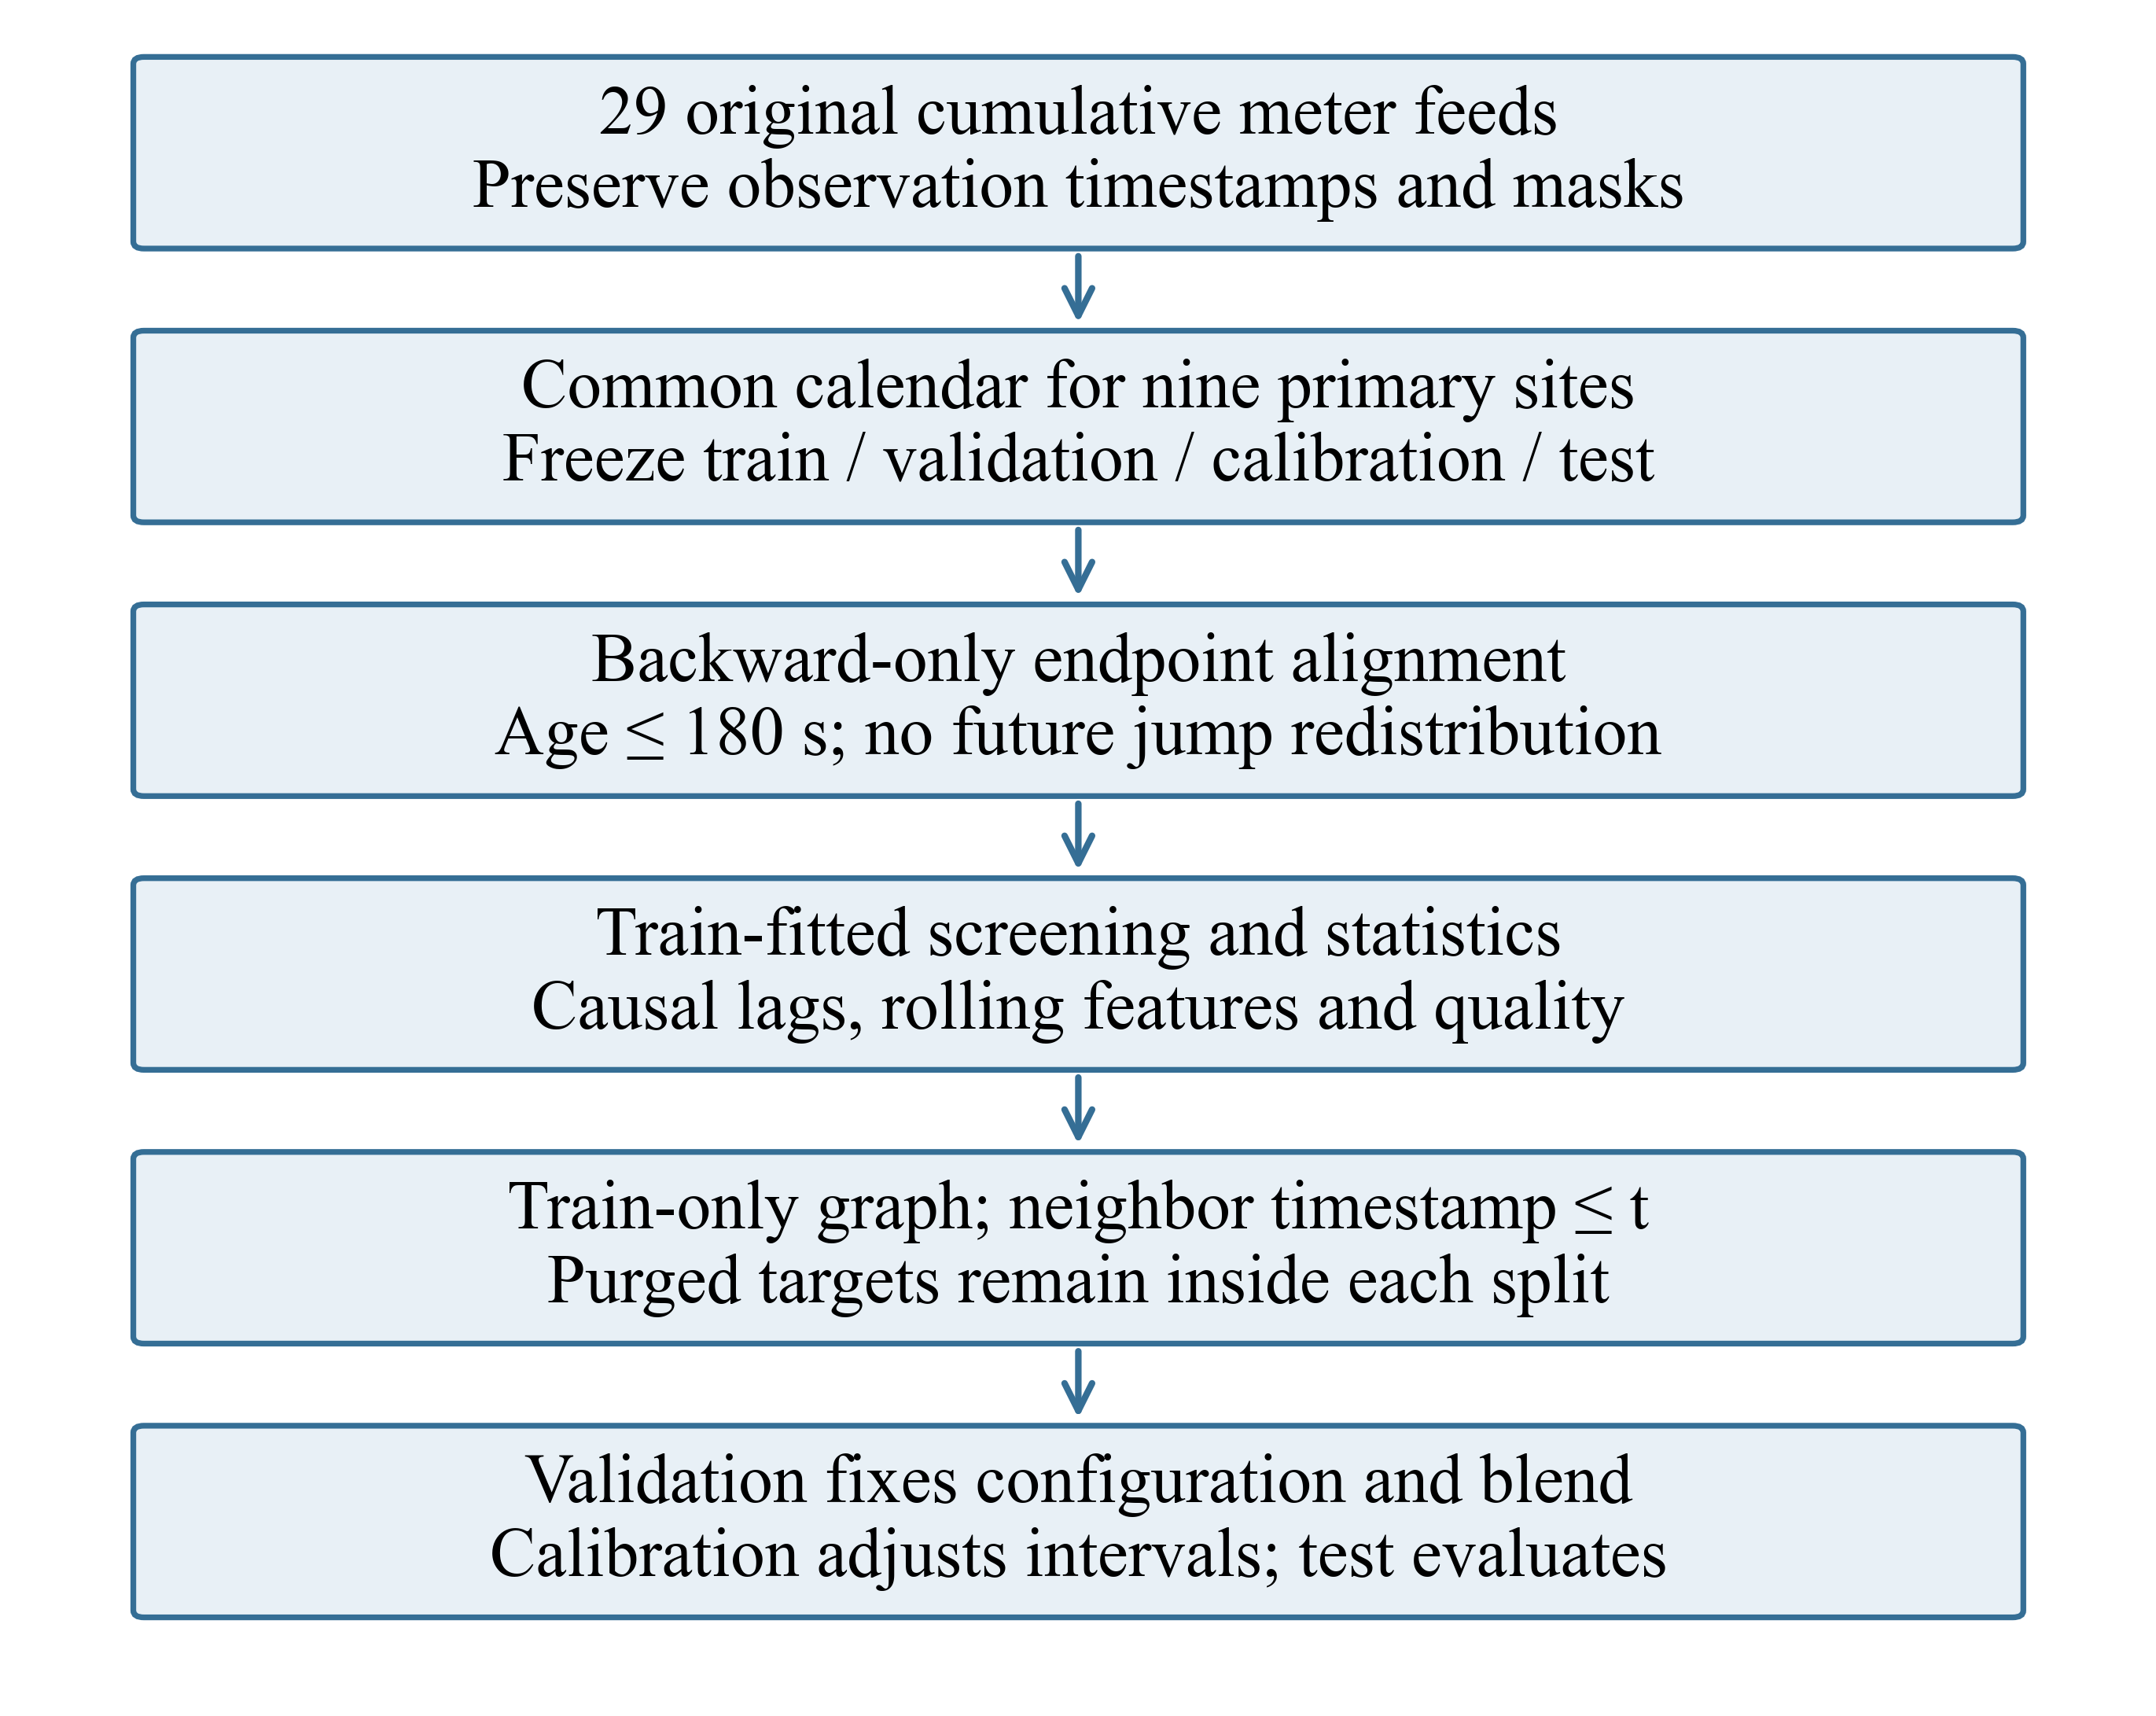

In [27]:
labels=['29 original cumulative meter feeds\nPreserve observation timestamps and masks','Common calendar for nine primary sites\nFreeze train / validation / calibration / test','Backward-only endpoint alignment\nAge ≤ 180 s; no future jump redistribution','Train-fitted screening and statistics\nCausal lags, rolling features and quality','Train-only graph; neighbor timestamp ≤ t\nPurged targets remain inside each split','Validation fixes configuration and blend\nCalibration adjusts intervals; test evaluates']
fig,ax=plt.subplots(figsize=(7.8, 6.2),layout='constrained');ax.set(xlim=(0,10),ylim=(-.3,12));ax.axis('off')
for j,label in enumerate(labels):
    y=11-2*j
    ax.add_patch(FancyBboxPatch((.6,y-.65),8.8,1.3,boxstyle='round,pad=.05',facecolor='#e8f0f6',edgecolor=C['blue'],linewidth=1.5))
    ax.text(5,y,label,ha='center',va='center',fontsize=18)
    if j<5:ax.annotate('',xy=(5,y-1.3),xytext=(5,y-.7),arrowprops={'arrowstyle':'->','lw':1.7,'color':C['blue']})
save_figure(fig,'revision_causal_preprocessing_pipeline',pd.DataFrame({'stage':range(1,7),'operation':labels}))


Every transform uses observations available at the forecast origin. The separate calibration period does not participate in model selection. Public-building supplementary cohorts retain separate calendars.

## Input missingness and train-fitted quality

Source: primary training panel; quality function fixed in the experiment configuration.

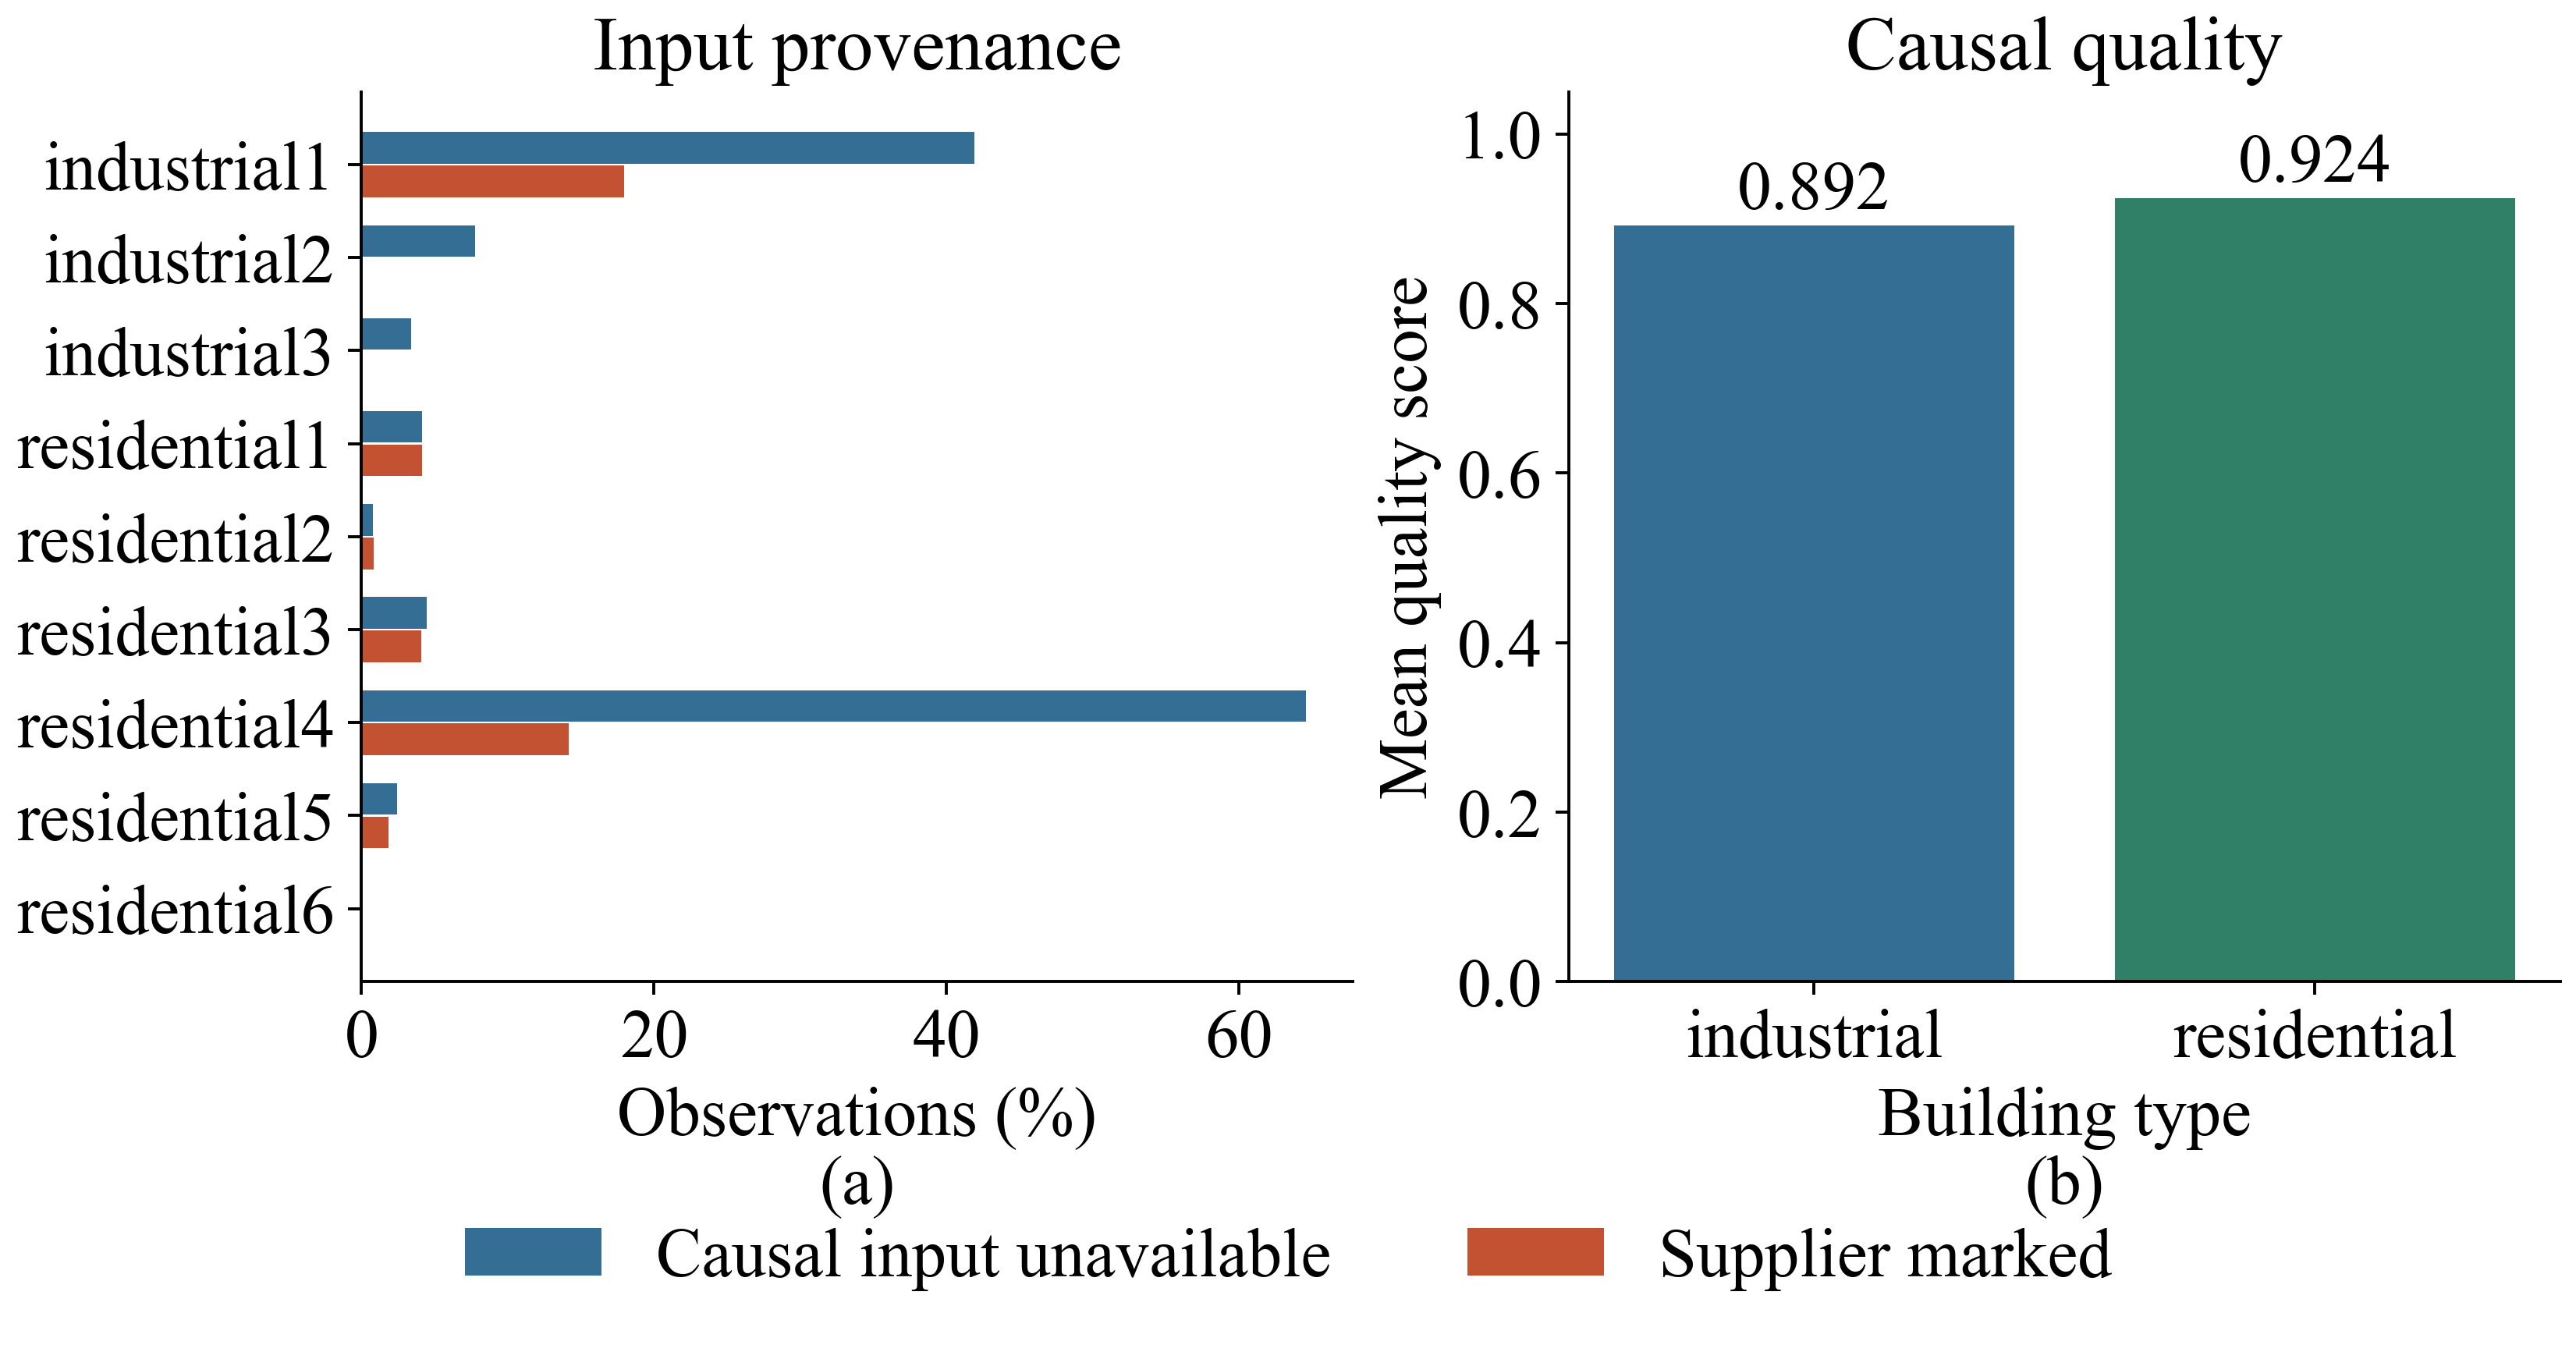

In [35]:
a=train_visual.groupby('site').agg(input_missing_fraction=('input_missing_flag','mean'),supplier_marked_fraction=('supplier_interpolated','mean'),mean_quality=('data_quality_score','mean')).sort_index()
b=train_visual.groupby('building_type').data_quality_score.mean()
fig,axes=plt.subplots(1,2,figsize=(9.4, 5.0),layout='constrained')
y=np.arange(len(a));axes[0].barh(y-.18,a.input_missing_fraction*100,height=.34,label='Causal input unavailable',color=C['blue']);axes[0].barh(y+.18,a.supplier_marked_fraction*100,height=.34,label='Supplier marked',color=C['orange'])
axes[0].set(yticks=y,yticklabels=a.index,xlabel='Observations (%)',title='Input provenance');axes[0].invert_yaxis()
axes[1].bar(b.index,b.values,color=[C['blue'],C['green']]);axes[1].set(ylim=(0,1.05),ylabel='Mean quality score',title='Causal quality',xlabel='Building type')
for j,v in enumerate(b):axes[1].text(j,v+.02,f'{v:.3f}',ha='center',fontsize=18)
outside_legend(fig,axes[0],2);panel_letters(axes);save_figure(fig,'revision_input_missingness_quality',a)


Supplier interpolation markers are incomplete provenance flags and are not treated as measured forecasting inputs. Input unavailability and supplier-marked interpolation are displayed separately.

## Absolute net-load ramps and PV regimes

Source: training net-load differences and train-defined PV regimes.

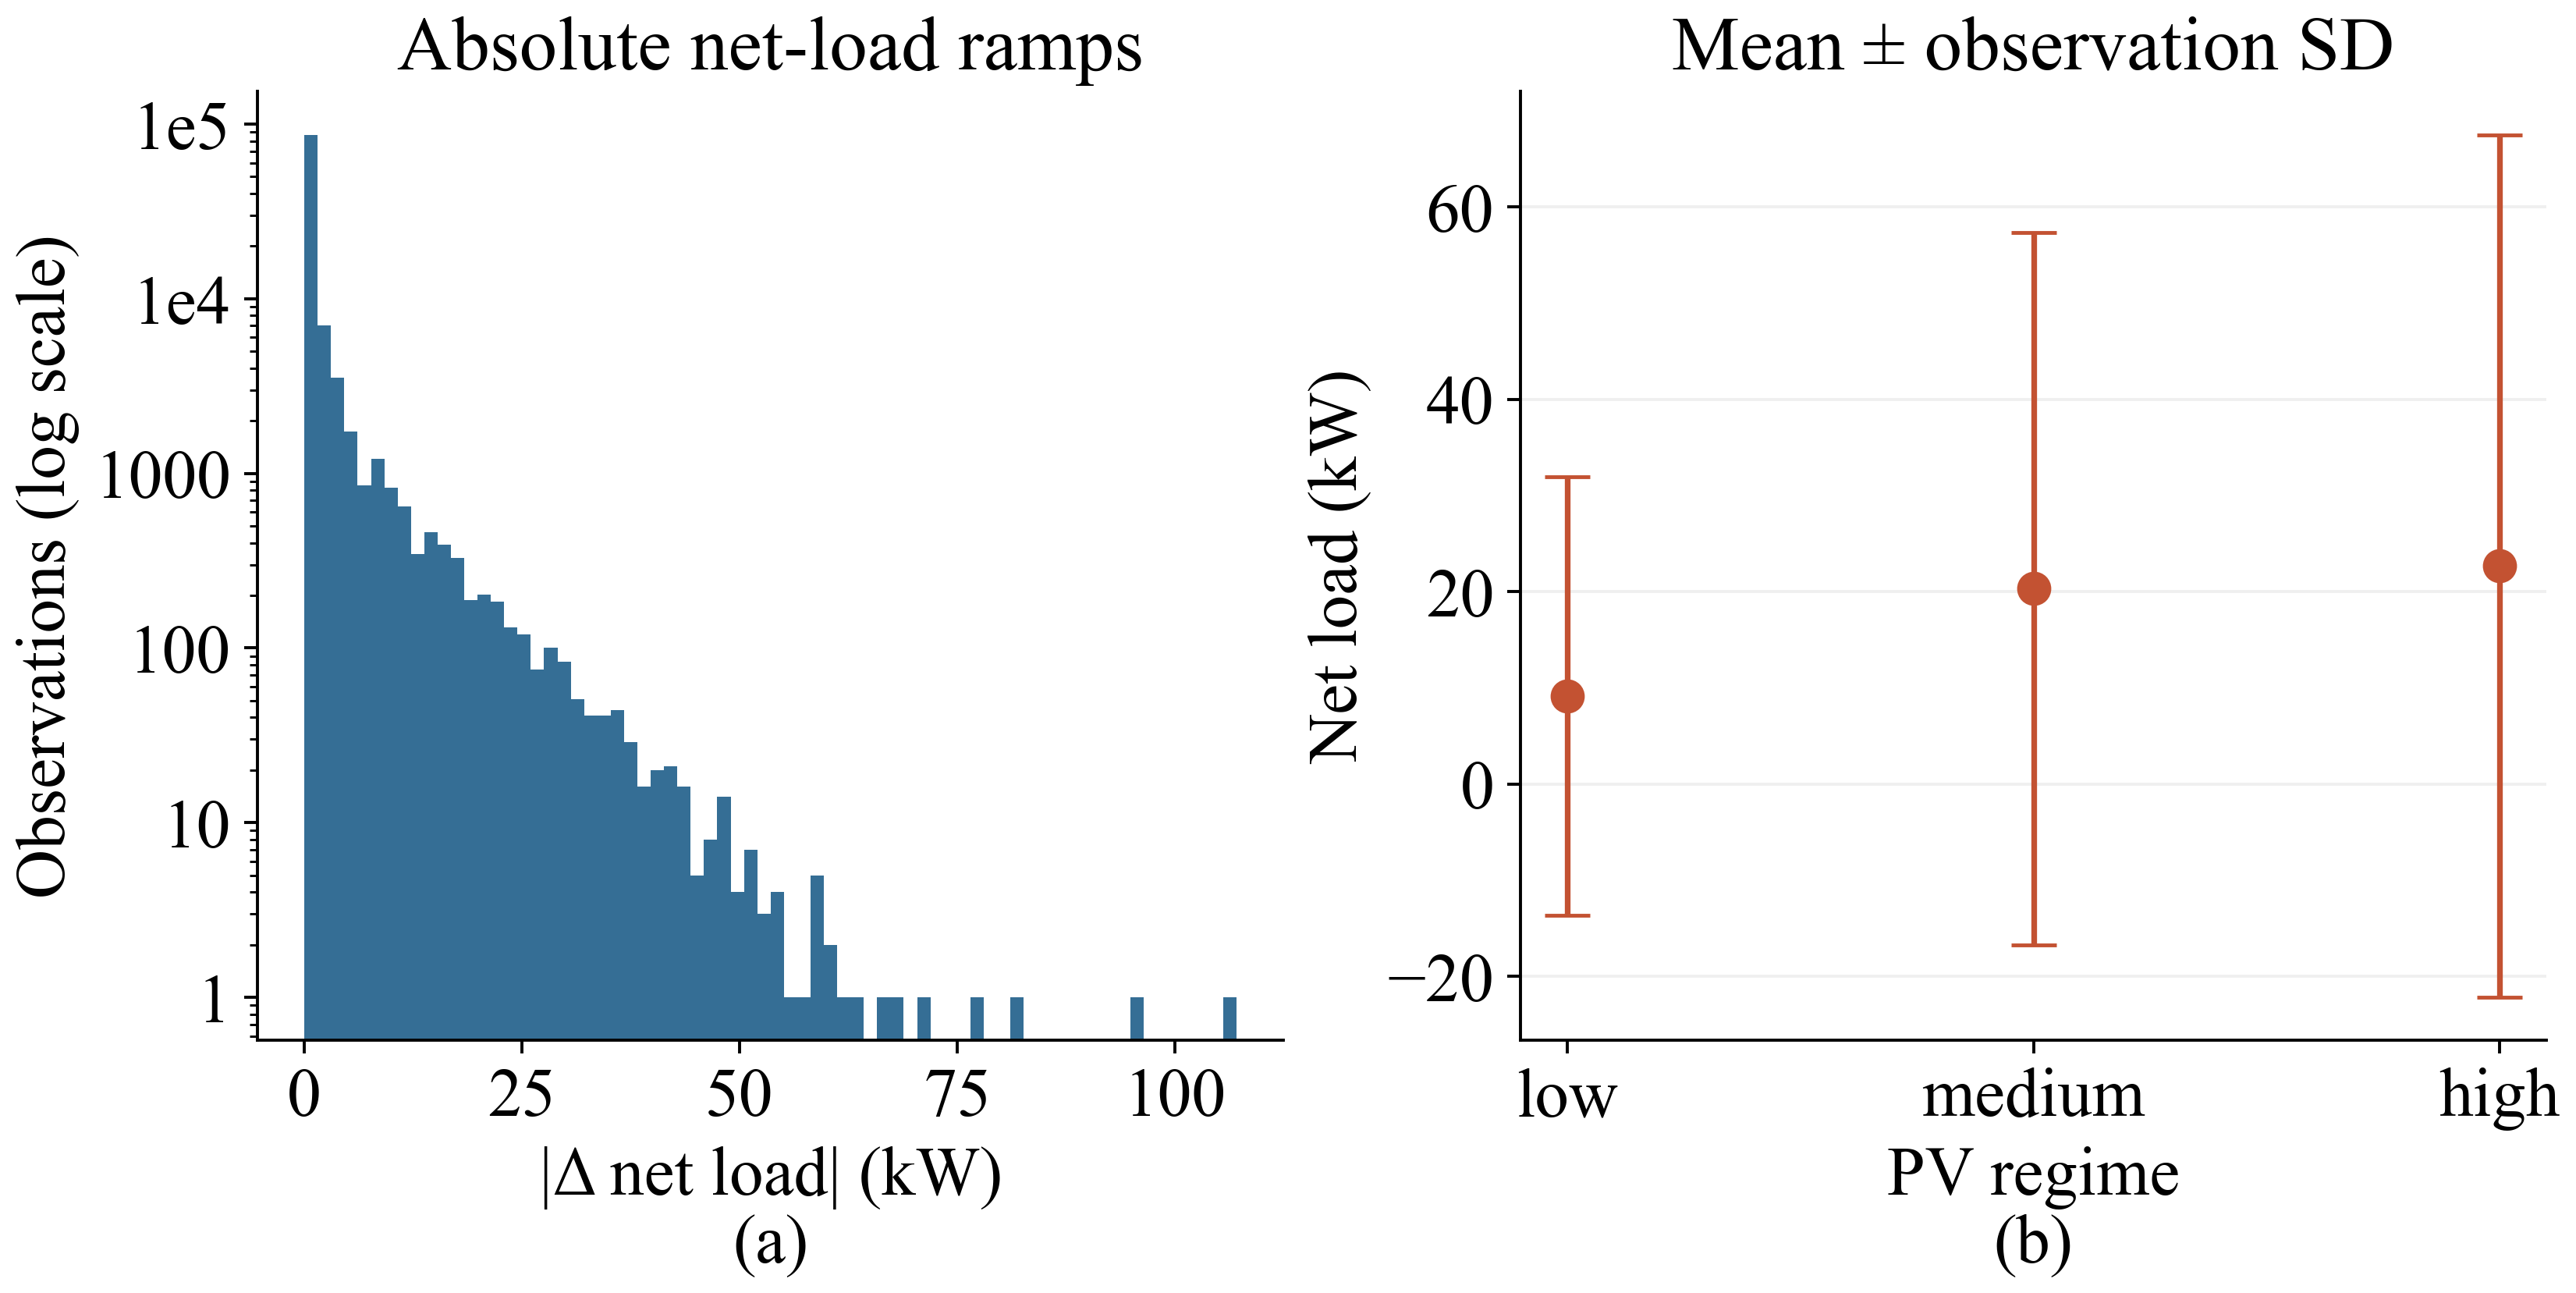

In [29]:
d=train_visual[['net_load_ramp_kw','pv_regime','net_load_kw']].copy();order=['low','medium','high']
g=d.groupby('pv_regime').net_load_kw.agg(['mean','std','count']).reindex(order)
fig,axes=plt.subplots(1,2,figsize=(9.4, 4.7),layout='constrained')
axes[0].hist(d.net_load_ramp_kw.abs().dropna(),bins=70,color=C['blue']);axes[0].set(yscale='log',xlabel='|Δ net load| (kW)',ylabel='Observations (log scale)',title='Absolute net-load ramps')
axes[1].errorbar(np.arange(3),g['mean'],yerr=g['std'],fmt='o',capsize=6,color=C['orange'],markersize=8)
axes[1].set(xticks=np.arange(3),xticklabels=order,xlabel='PV regime',ylabel='Net load (kW)',title='Mean ± observation SD');axes[1].grid(axis='y',alpha=.2)
panel_letters(axes);save_figure(fig,'revision_ramps_and_pv_regimes',g)


Rapid-ramp status is based on the absolute change and a train-only site threshold, so large negative ramps are also detected. Error bars describe observation spread, not uncertainty in a model comparison.

## Within-site lag correlation matrix

Source: training-only feature panel; pair counts exported with correlations.

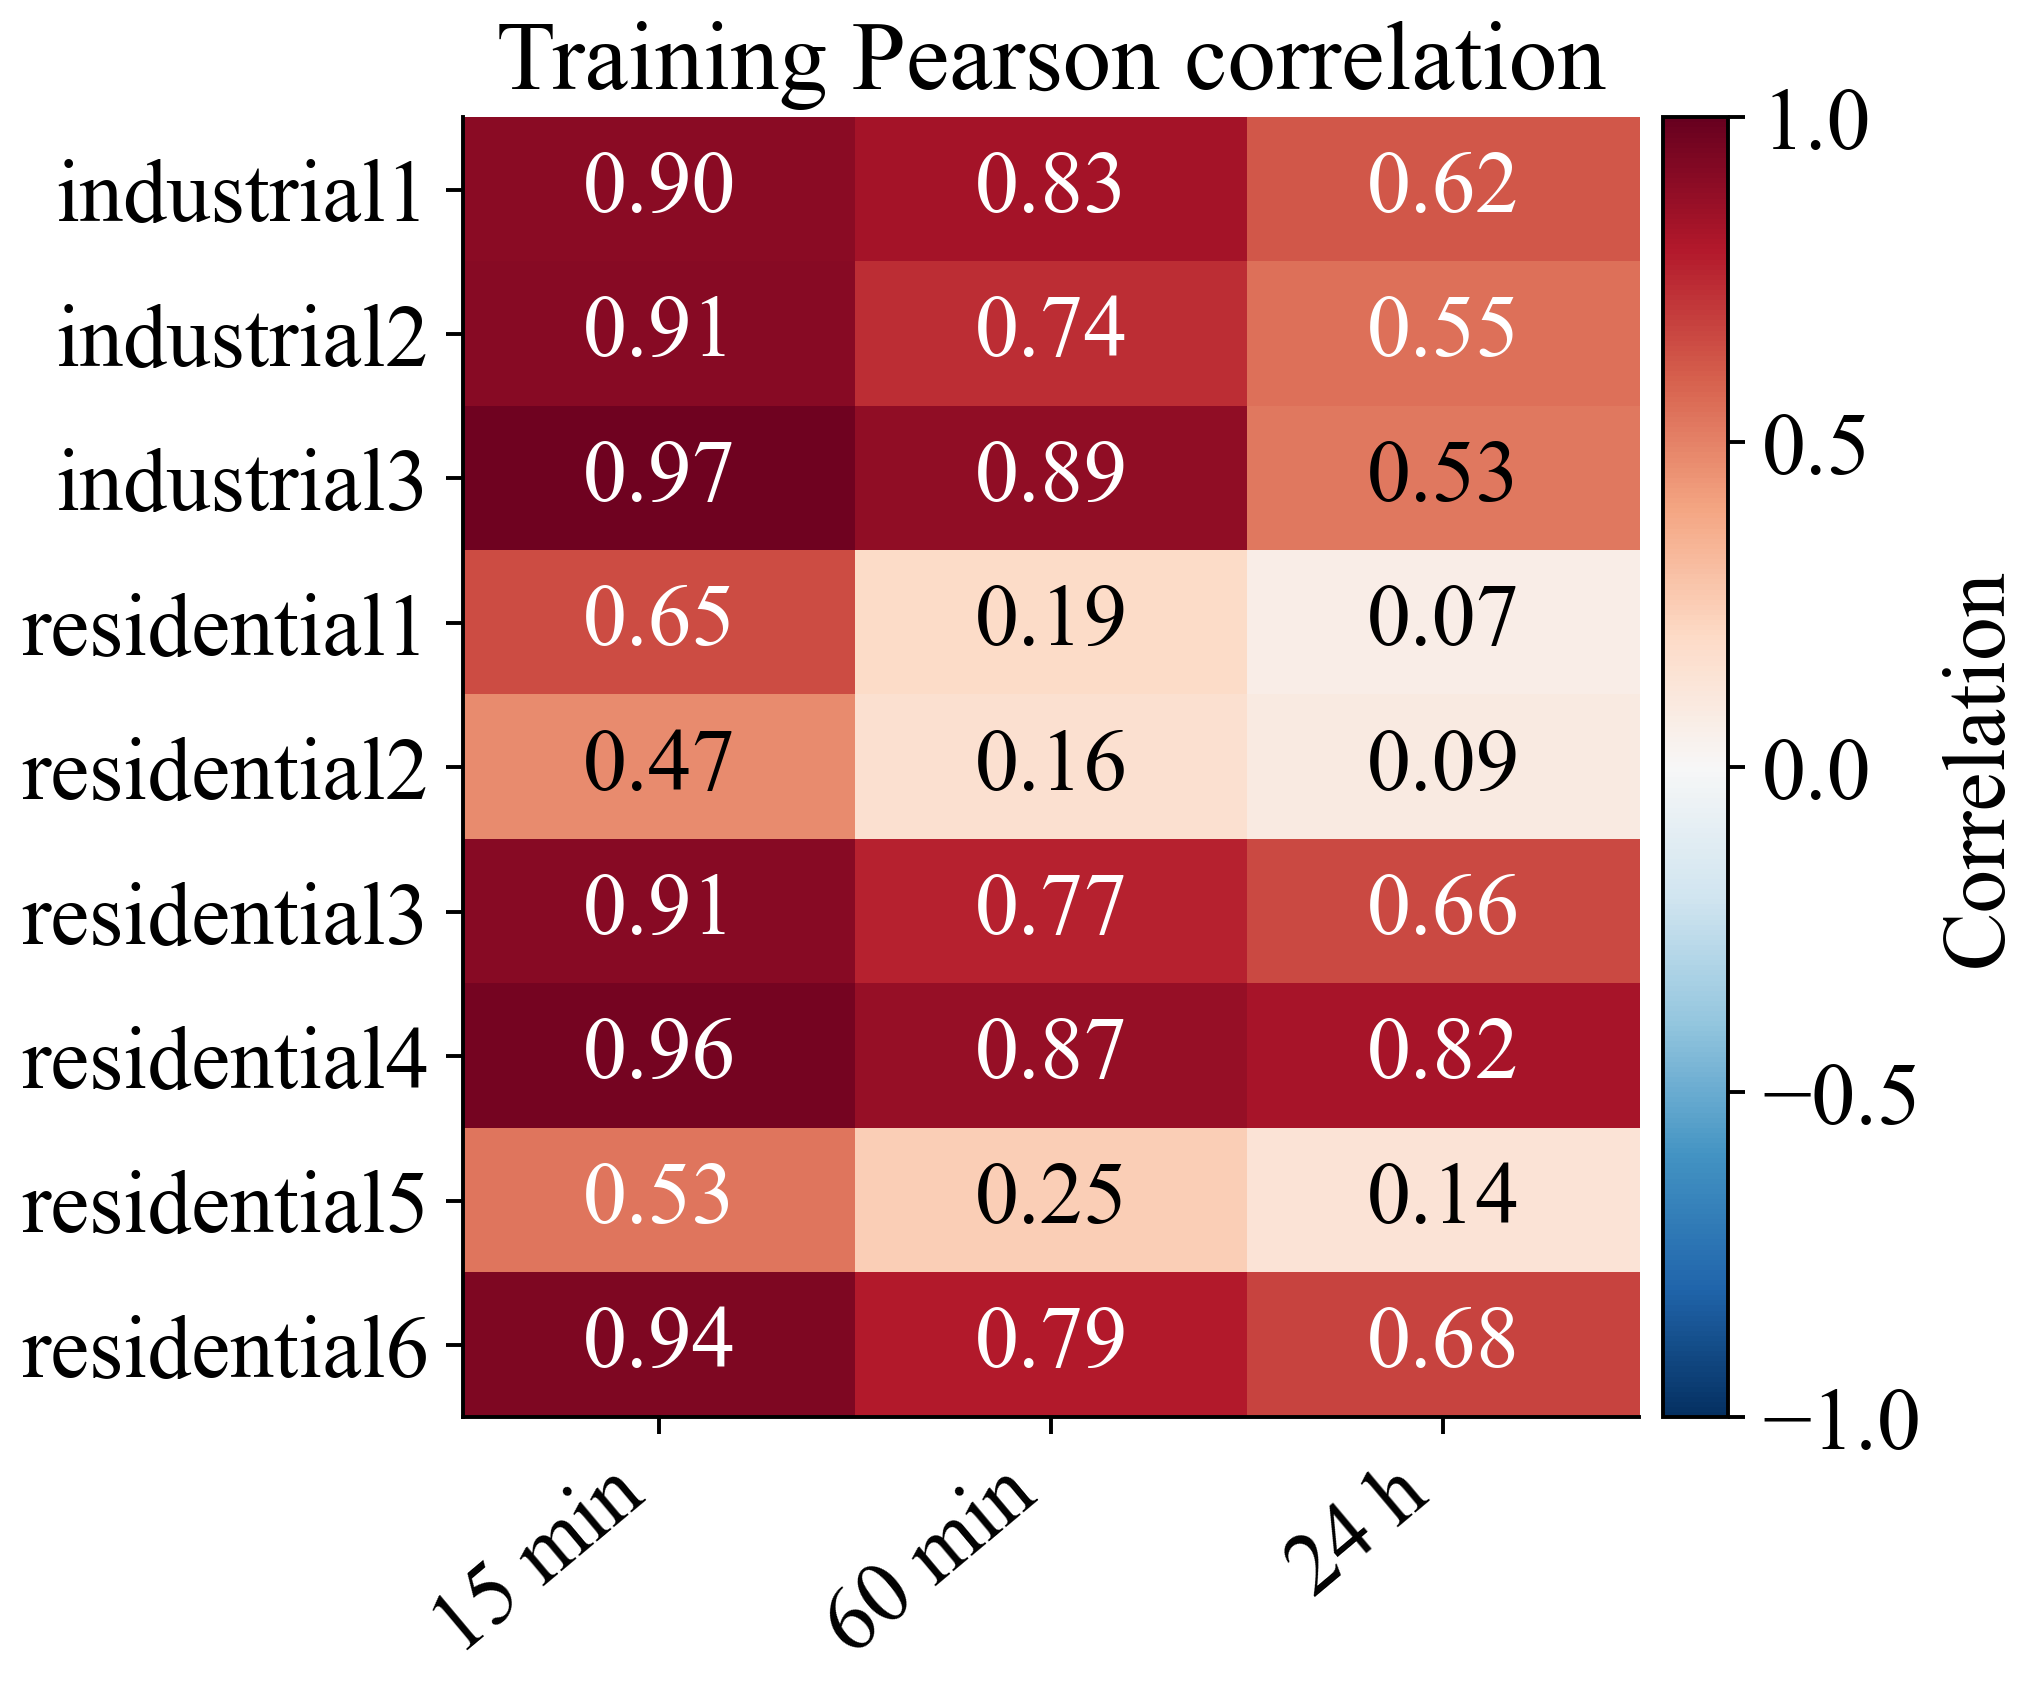

In [30]:
source=pd.read_csv(VISUAL_DATA/'revision_lag_correlation_matrix.csv',index_col=0)
matrix=source.pivot(index='site',columns='lag',values='correlation').reindex(columns=['15 min','60 min','24 h'])
fig,ax=plt.subplots(figsize=(5.8, 4.8),layout='constrained');labelled_matrix(ax,matrix,'Training Pearson correlation',cmap='RdBu_r',vmin=-1,vmax=1,cbar_label='Correlation')
save_figure(fig,'revision_lag_correlation_matrix',source)


Correlations are calculated within each site from available training pairs. They are descriptive diagnostics; test data do not determine the lag set or graph.

## Daily load profiles in the primary cohort

Source: measured primary training observations; local clock incorporates Europe/Berlin daylight saving.

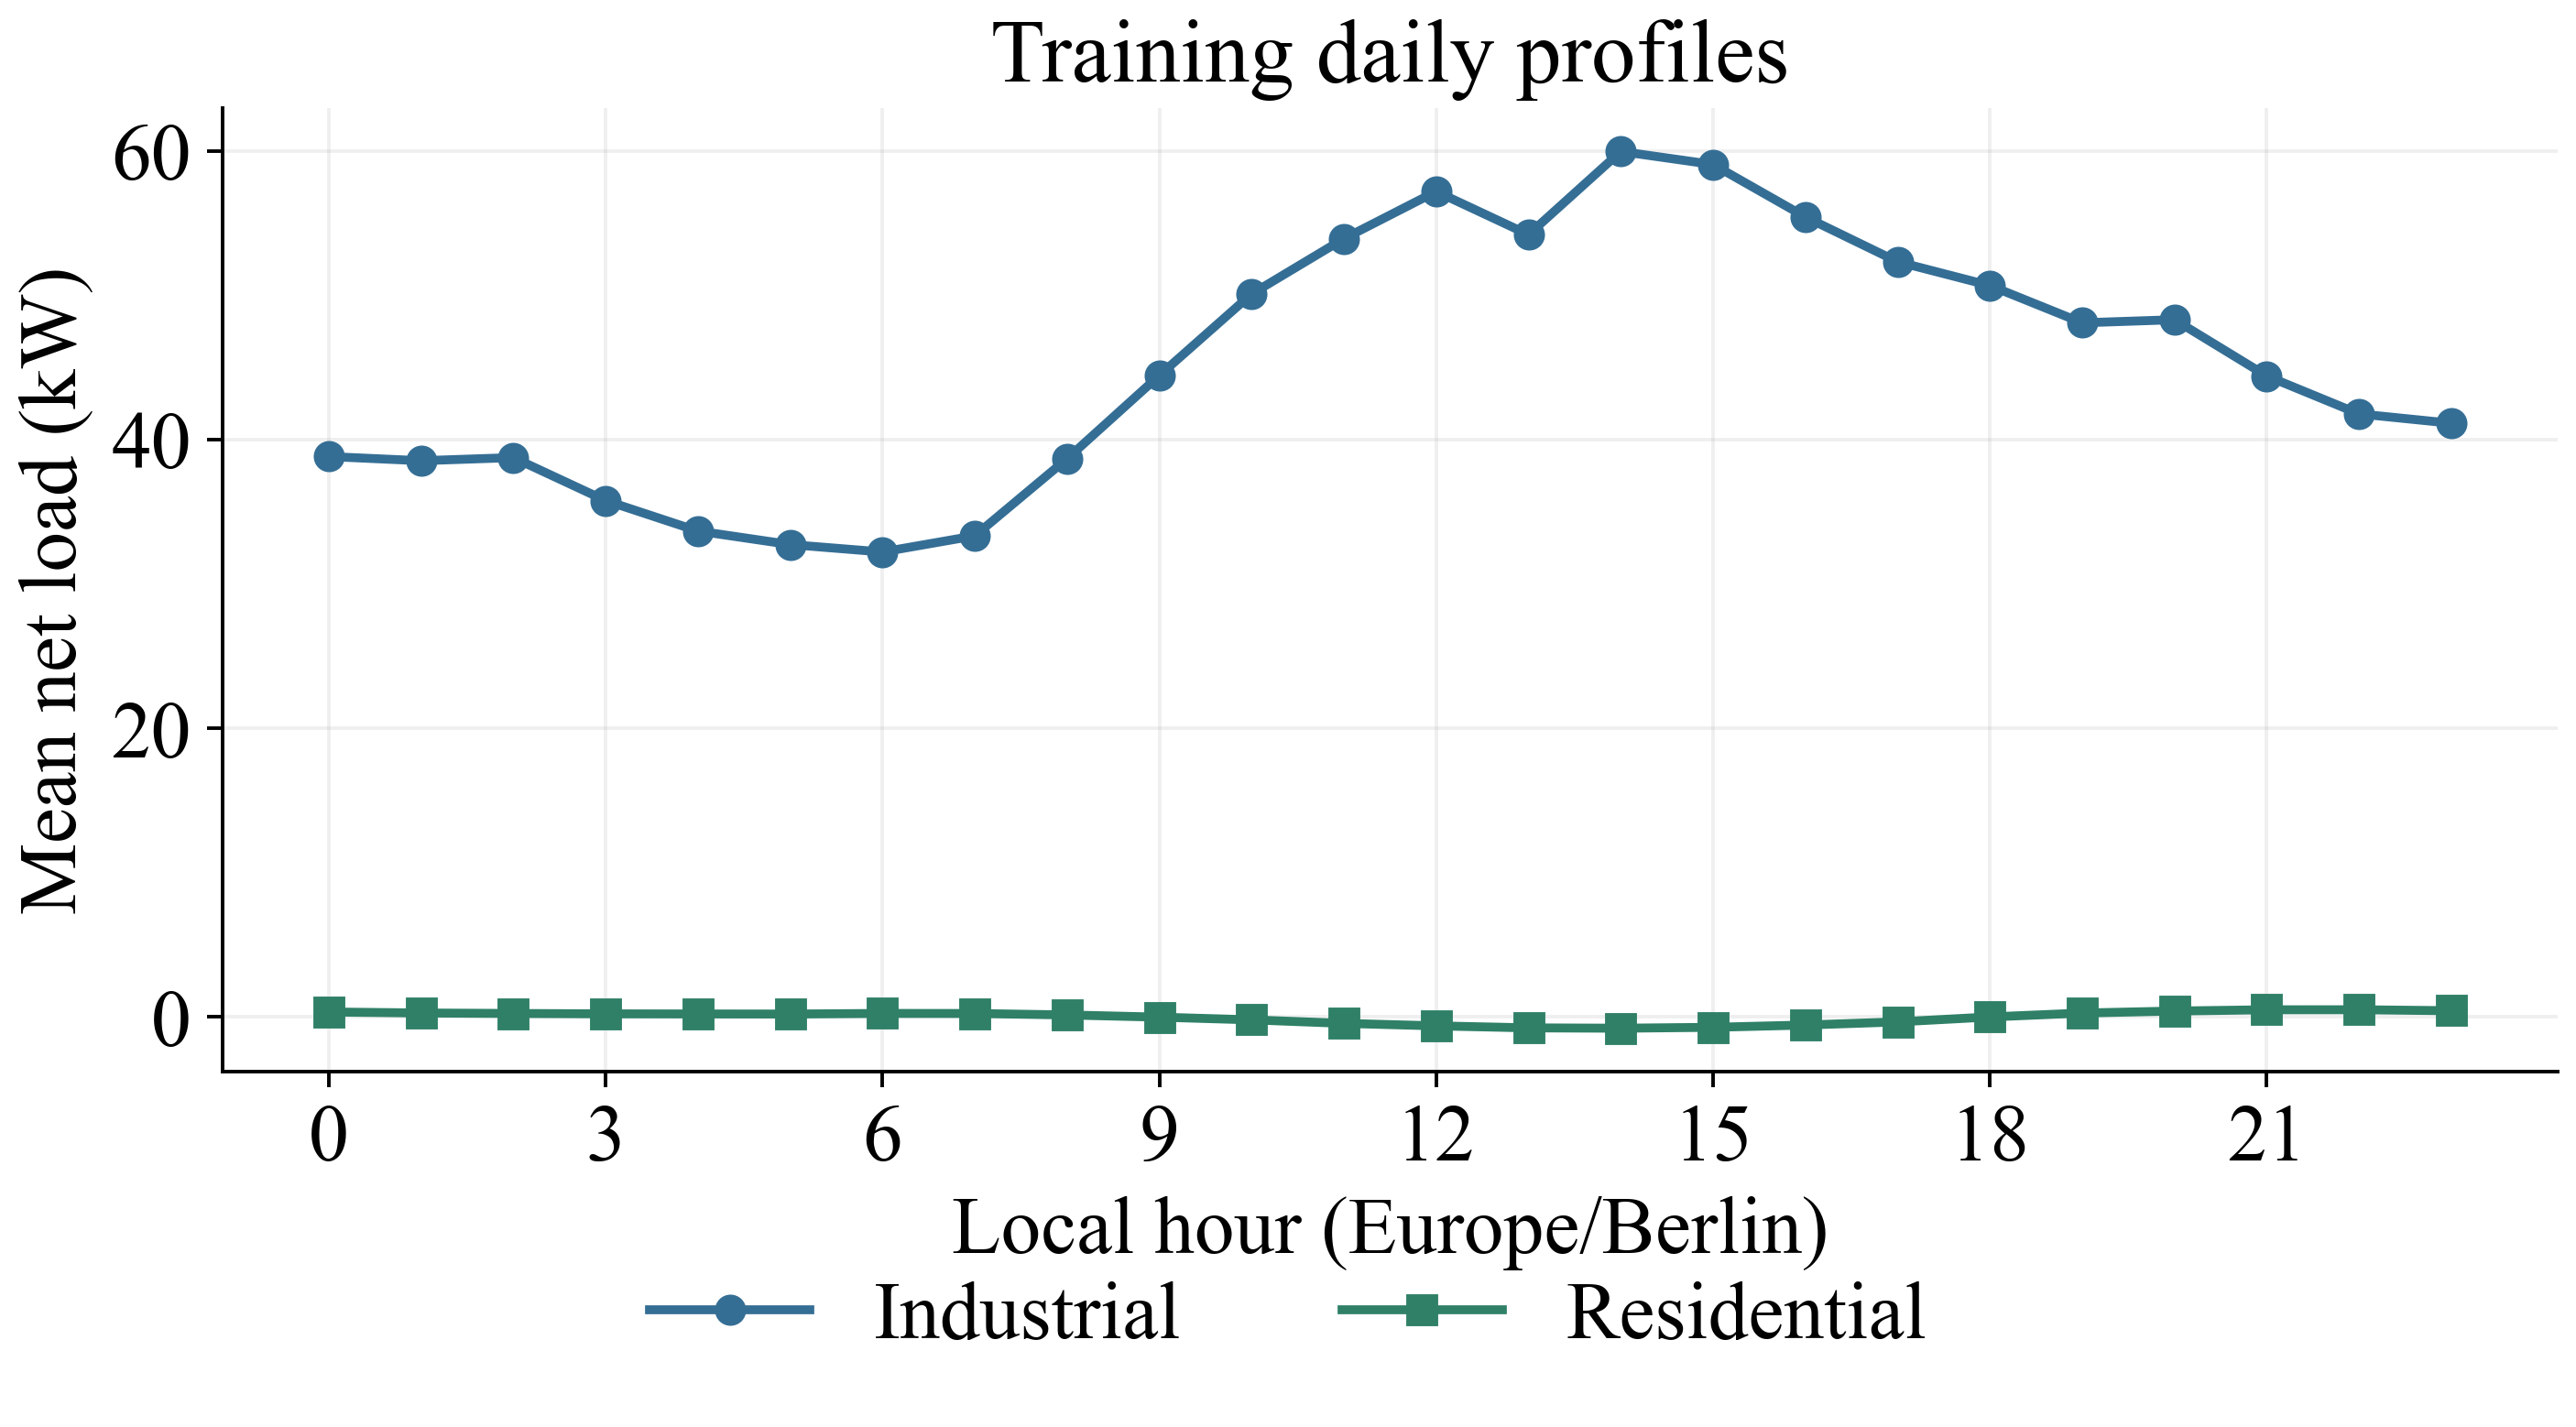

In [31]:
g=pd.read_csv(VISUAL_DATA/'revision_daily_load_profiles.csv',index_col=0)
fig,ax=plt.subplots(figsize=(8, 4.5),layout='constrained')
for typ,color,marker in [('industrial',C['blue'],'o'),('residential',C['green'],'s')]:
    z=g.loc[g.building_type.eq(typ)];ax.plot(z.hour,z['mean'],label=typ.capitalize(),color=color,marker=marker,linewidth=2)
ax.set(xlabel='Local hour (Europe/Berlin)',ylabel='Mean net load (kW)',xticks=np.arange(0,24,3),title='Training daily profiles');ax.grid(alpha=.2)
outside_legend(fig,ax,2);save_figure(fig,'revision_daily_load_profiles',g)


Only industrial and residential sites share the primary calendar. Public-site results are shown in a separate supplementary-cohort analysis rather than pooled into this profile.

## Common-calendar partition for the nine-site cohort

All sites share the same training, validation, calibration and test boundaries.

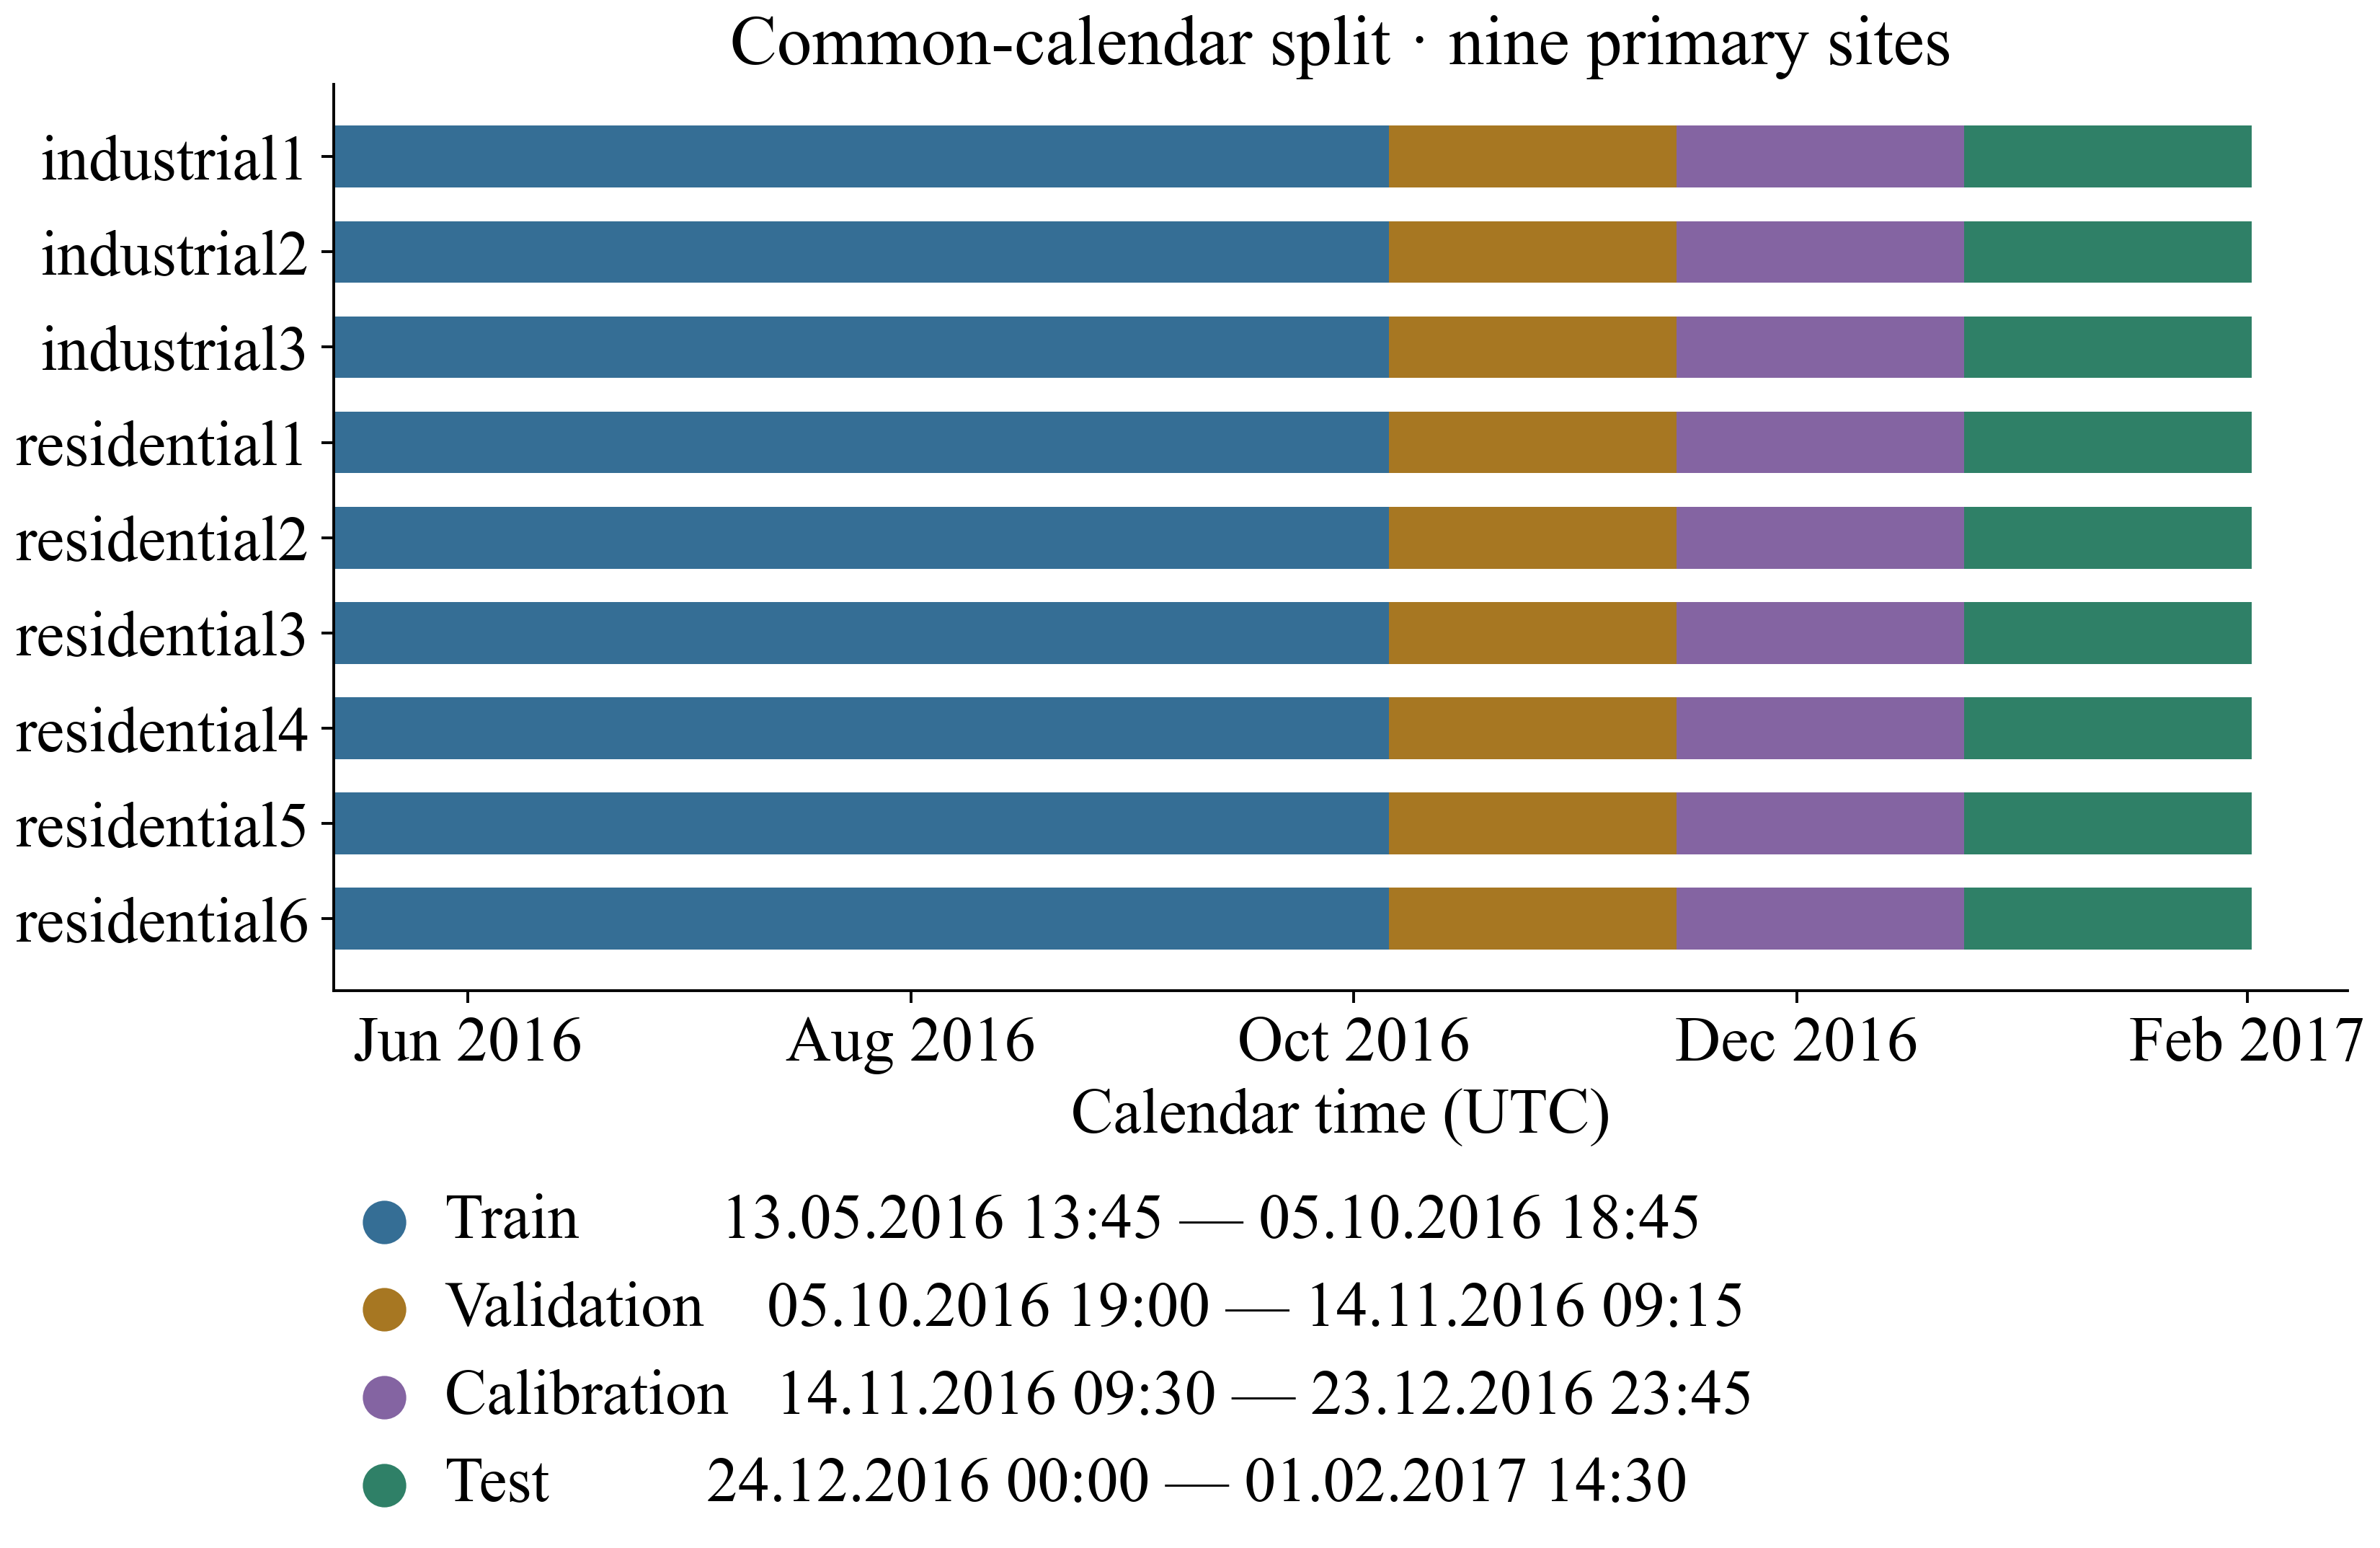

In [32]:
splits=pd.read_csv(TABLE_DIR/'split_summary.csv',parse_dates=['start','end'])
assert splits.split.tolist()==['train','validation','calibration','test']
expected=[('2016-05-13 13:45','2016-10-05 18:45'),('2016-10-05 19:00','2016-11-14 09:15'),('2016-11-14 09:30','2016-12-23 23:45'),('2016-12-24 00:00','2017-02-01 14:30')]
for row,(start,end) in zip(splits.itertuples(),expected):assert row.start==pd.Timestamp(start,tz='UTC') and row.end==pd.Timestamp(end,tz='UTC')
sites=sorted(modeling.site.unique());assert len(sites)==9
fig=plt.figure(figsize=(9.4, 6.1),layout='constrained');gs=fig.add_gridspec(2,1,height_ratios=[2.6,1.05]);ax=fig.add_subplot(gs[0]);notes=fig.add_subplot(gs[1]);notes.axis('off')
colors=[C['blue'],C['gold'],C['purple'],C['green']]
for row,color in zip(splits.itertuples(),colors):
    start=mdates.date2num(row.start);end=mdates.date2num(row.end+pd.Timedelta(minutes=15))
    ax.barh(np.arange(9),end-start,left=start,height=.65,color=color,label=row.split.capitalize())
ax.set(yticks=np.arange(9),yticklabels=sites,xlabel='Calendar time (UTC)',title='Common-calendar split · nine primary sites');ax.invert_yaxis();ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2));ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'));ax.tick_params(axis='x',rotation=0)
for tick in ax.get_xticklabels():tick.set_ha('center')
ax.legend(loc='outside lower center') if False else None
for j,(row,color) in enumerate(zip(splits.itertuples(),colors)):
    y=.85-j*.24;notes.scatter(.025,y,color=color,s=130,transform=notes.transAxes)
    notes.text(.055,y,f'{row.split.capitalize():12s}  {row.start:%d.%m.%Y %H:%M} — {row.end:%d.%m.%Y %H:%M}',transform=notes.transAxes,va='center',fontsize=18)
save_figure(fig,'revision_common_calendar_four_way_split',splits)


The same inclusive chronological boundaries apply to all nine primary sites. Calibration follows model selection. Bars extend by one 15-minute step to show continuous calendar intervals.

## Graph context and ramp–PV relationships

Source: training graph features and available meter-derived inputs.

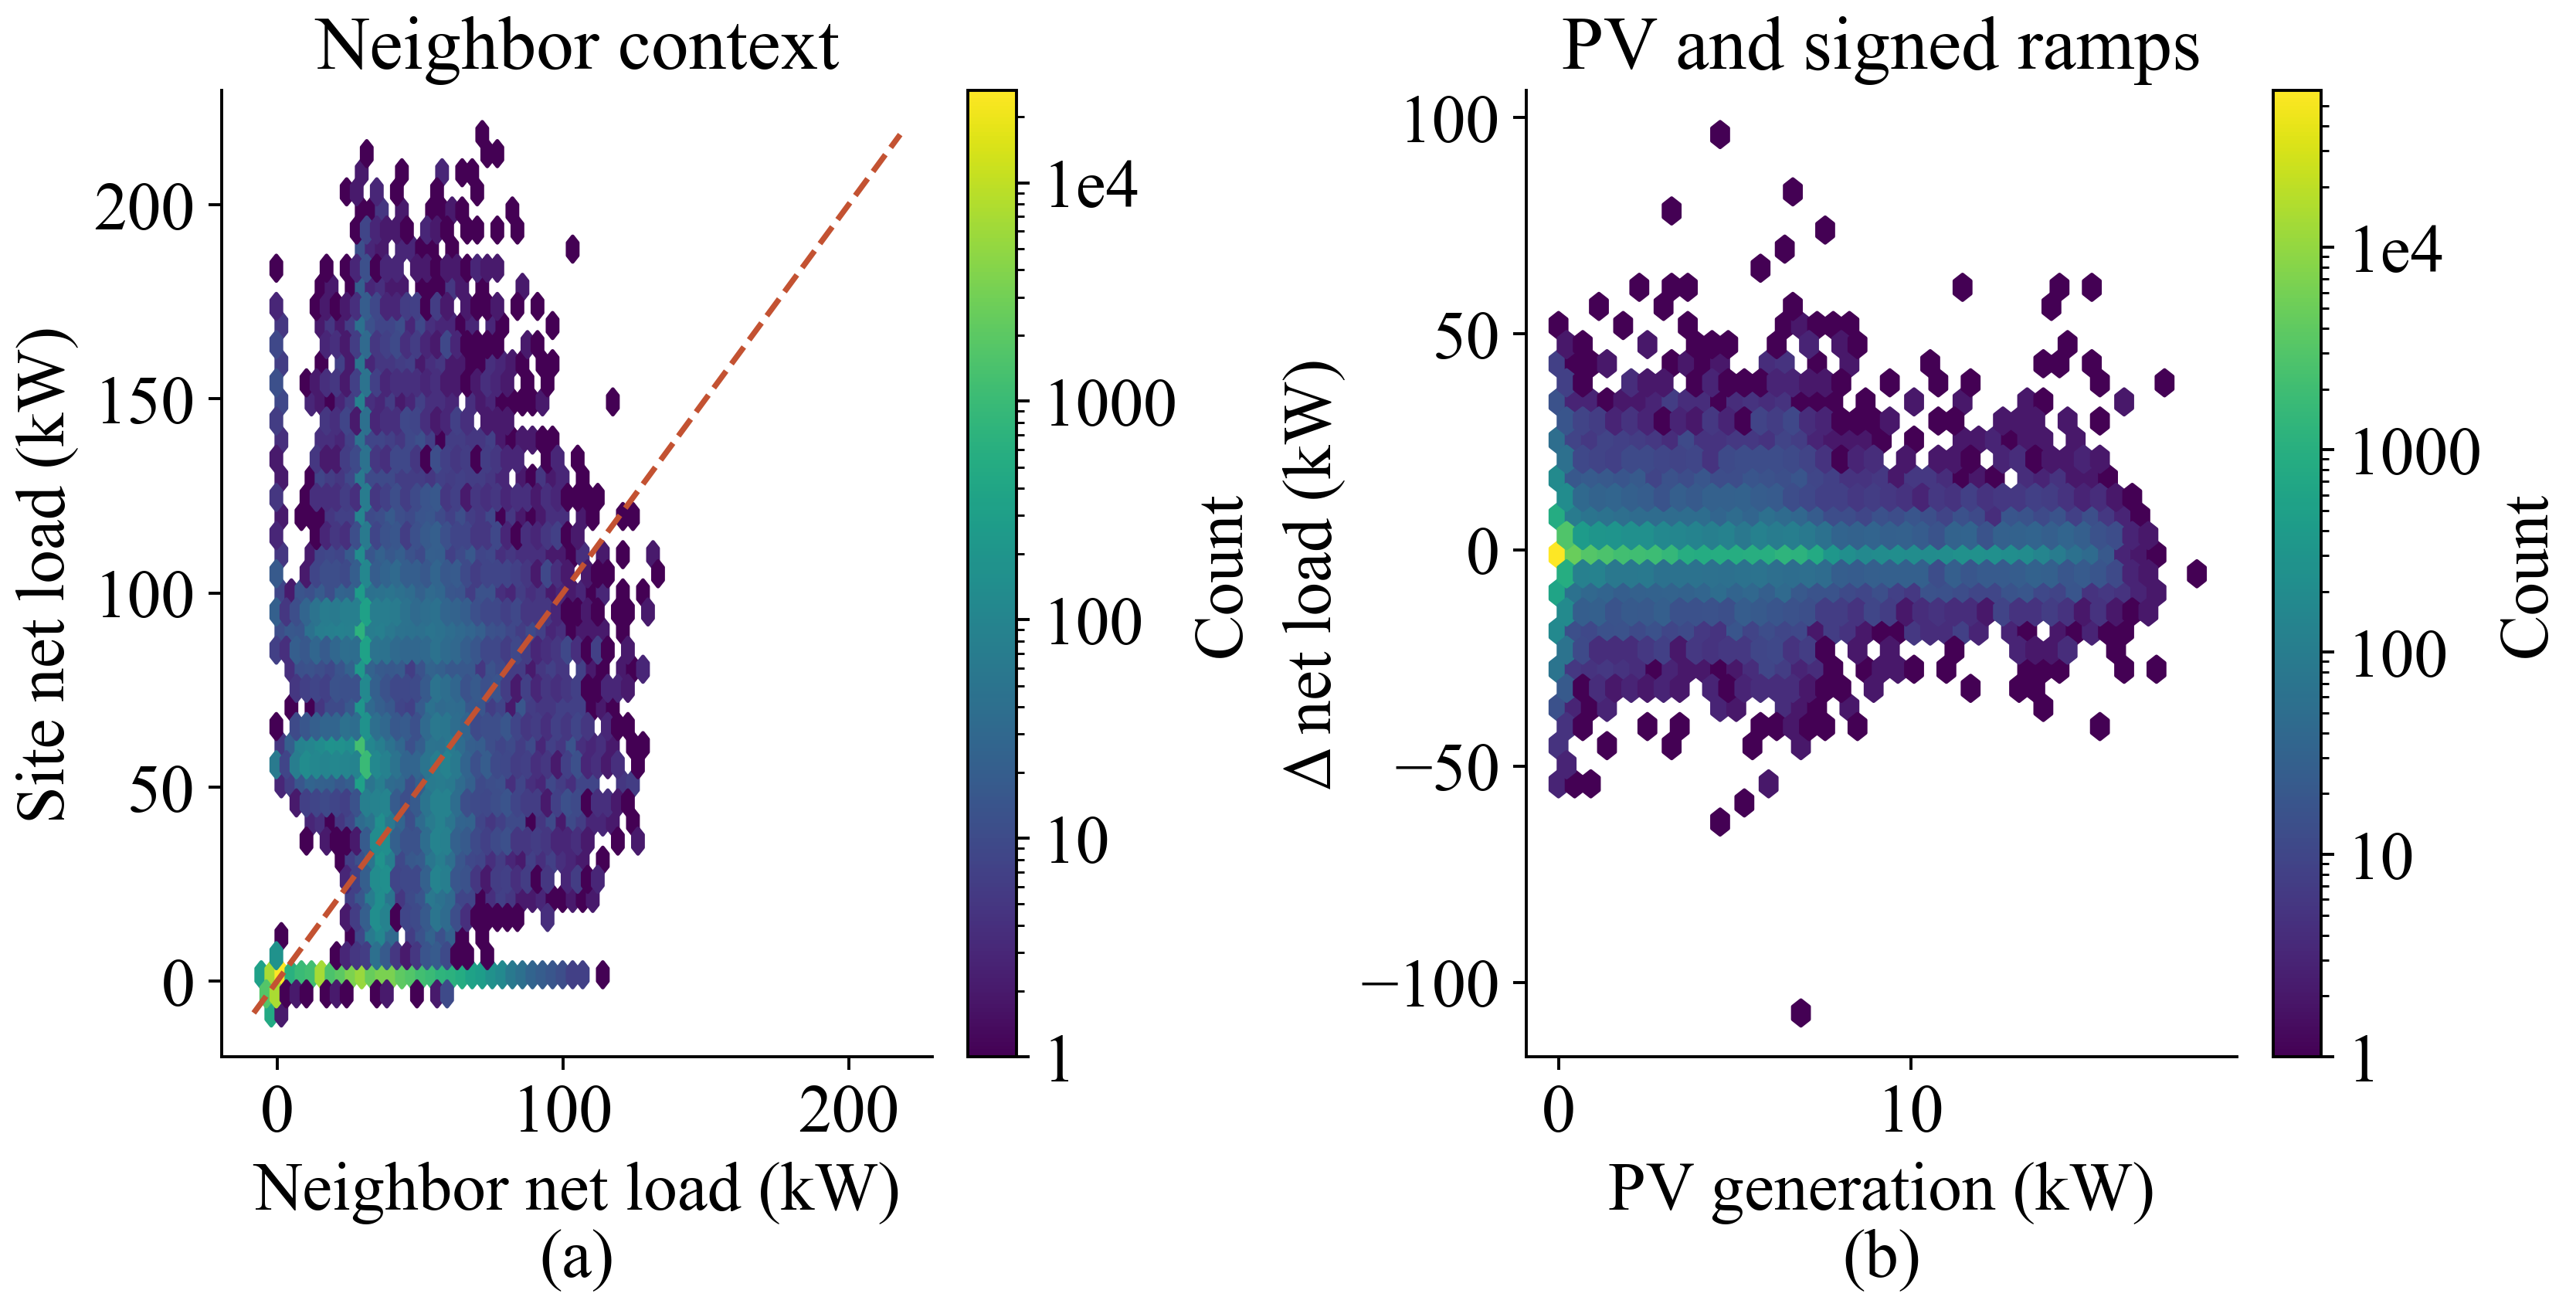

In [33]:
d=pd.read_csv(VISUAL_DATA/'revision_graph_context_relationships.csv',index_col=0)
fig,axes=plt.subplots(1,2,figsize=(9.5, 4.8),layout='constrained')
for ax,x,y,title in [(axes[0],'graph_neighbor_net_load_kw','net_load_kw','Neighbor context'),(axes[1],'pv_power_kw','net_load_ramp_kw','PV and signed ramps')]:
    im=ax.hexbin(d[x],d[y],gridsize=40,mincnt=1,bins='log',cmap='viridis');fig.colorbar(im,ax=ax).set_label('Count');ax.set(title=title)
axes[0].set(xlabel='Neighbor net load (kW)',ylabel='Site net load (kW)')
lo=min(d.net_load_kw.min(),d.graph_neighbor_net_load_kw.min());hi=max(d.net_load_kw.max(),d.graph_neighbor_net_load_kw.max());axes[0].plot([lo,hi],[lo,hi],'--',color=C['orange'])
axes[1].set(xlabel='PV generation (kW)',ylabel='Δ net load (kW)')
panel_letters(axes);save_figure(fig,'revision_graph_context_relationships',d)


Graph weights are learned on train only; contemporaneous neighbor inputs are available no later than the forecast origin. The scatter is descriptive and does not establish a causal PV effect.

## Train-only graph adjacency matrix

Source: exact graph weights stored in `main_preprocessing_state.json`.

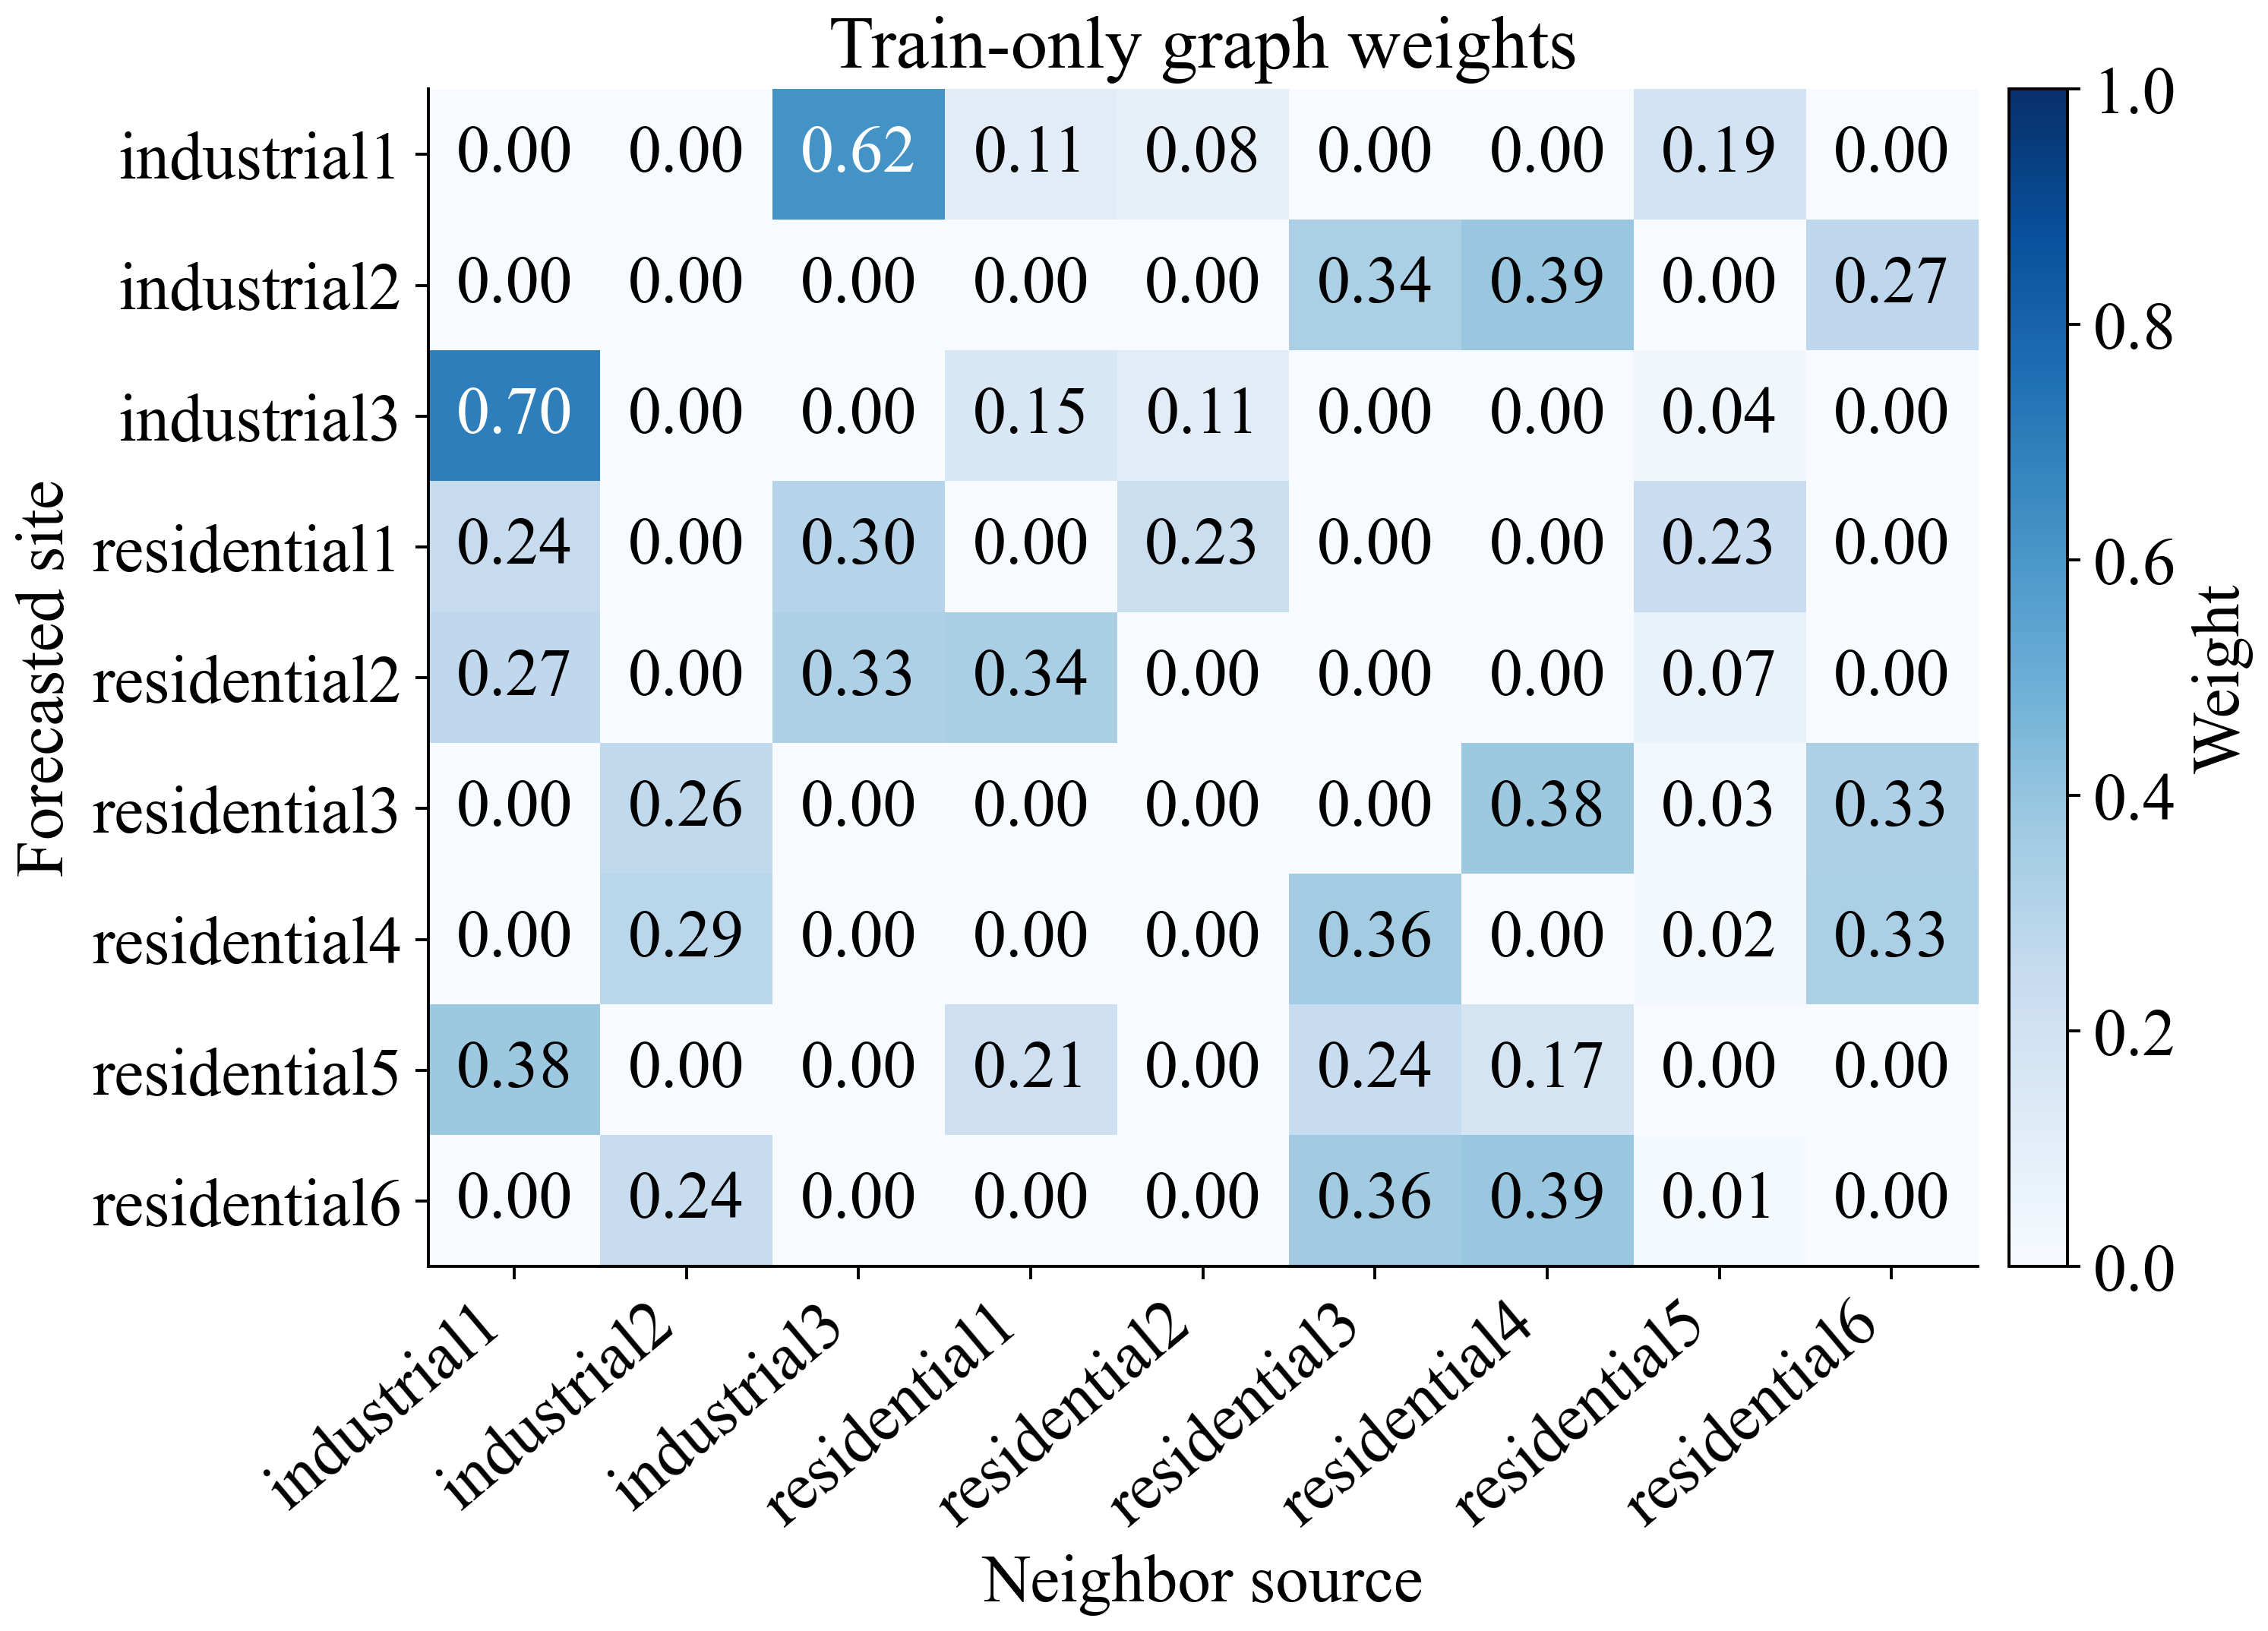

In [34]:
state=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text());sites=state['graph_sites']
w=pd.DataFrame(state['graph_weights']).reindex(index=sites,columns=sites)
assert np.allclose(np.diag(w),0) and (w.to_numpy()>=0).all()
fig,ax=plt.subplots(figsize=(8.5, 6.1),layout='constrained');labelled_matrix(ax,w,'Train-only graph weights',cmap='Blues',vmin=0,vmax=1,cbar_label='Weight');ax.set(xlabel='Neighbor source',ylabel='Forecasted site')
save_figure(fig,'revision_graph_adjacency_matrix',w)


Rows identify forecasted sites and columns identify neighbor sources. Self-edges are excluded. Top-neighbor selection and row normalization can make the weight matrix asymmetric even when the underlying correlations are symmetric.